## C) Finance Example: European Call Option with MLMC

### MLMC for Geometric Brownian Motion

We now apply the MLMC framework to price a **European call option** under the Black-Scholes model, where the stock price follows GBM.

# Multi-Level Monte Carlo Methods: A Comprehensive Tutorial

**Author**: Tutorial for Wadoud Charbak  
**Context**: KAUST Quantitative Research - American Basket Options with Markovian Projection  
**Objective**: Learn MLMC fundamentals, theory, and applications in quantitative finance

---

## Tutorial Structure

Each major topic follows a four-part structure:

**A) Mathematical Foundation** - Rigorous LaTeX derivations and theoretical results  
**B) General Code Examples** - Physics and mathematics problems for intuition  
**C) Finance Examples** - Options pricing, American options, Markovian Projection  
**D) Physics Intuition** - Connections to statistical mechanics, QFT, computational physics

---

## Table of Contents

1. [Monte Carlo Fundamentals](#chapter1)
2. [Variance Reduction Techniques](#chapter2)
3. [Two-Level Monte Carlo](#chapter3)
4. [Multi-Level Monte Carlo Theory](#chapter4)
5. [MLMC for Stochastic Differential Equations](#chapter5)
6. [Implementation and Diagnostics](#chapter6)
7. [Discontinuous Payoffs](#chapter7)
8. [American Options and Optimal Stopping](#chapter8)
9. [Markovian Projection for Dimension Reduction](#chapter9)
10. [MLMC for American Options](#chapter10)

---

## Key References

1. **Giles, M.B. (2008)** - "Multilevel Monte Carlo path simulation", *Operations Research* 56(3), pp. 607-617
2. **Giles, M.B. (2015)** - "Multilevel Monte Carlo methods", *Acta Numerica* 24, pp. 259-328
3. **Longstaff, F.A. & Schwartz, E.S. (2001)** - "Valuing American options by simulation: A simple least-squares approach", *The Review of Financial Studies* 14(1), pp. 113-147
4. **Kloeden, P.E. & Platen, E. (1992)** - *Numerical Solution of Stochastic Differential Equations*, Springer
5. **Glasserman, P. (2004)** - *Monte Carlo Methods in Financial Engineering*, Springer

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Callable, Tuple, List, Dict
import time

# Set random seed for reproducibility
np.random.seed(42)

# Matplotlib settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['lines.linewidth'] = 2

print("Imports successful. NumPy version:", np.__version__)

Imports successful. NumPy version: 2.2.6


---
<a id='chapter1'></a>
# Chapter 1: Monte Carlo Fundamentals

Monte Carlo (MC) methods are computational algorithms that use repeated random sampling to obtain numerical results. The name originates from the Monte Carlo Casino in Monaco, reflecting the method's reliance on randomness.

## A) Mathematical Foundation

### 1.1 The Monte Carlo Estimator

Suppose we want to estimate the expectation of a random variable $X$:

$$
\mu = \mathbb{E}[X] = \int_{-\infty}^{\infty} x \, p(x) \, dx
$$

where $p(x)$ is the probability density function of $X$.

The **Monte Carlo estimator** is based on drawing $N$ independent samples $X^{(1)}, X^{(2)}, \ldots, X^{(N)}$ from the distribution $p(x)$ and computing the sample mean:

$$
\bar{X}_N = \frac{1}{N} \sum_{n=1}^{N} X^{(n)}
$$

### 1.2 The Law of Large Numbers

**Theorem (Strong Law of Large Numbers)**: If $X^{(1)}, X^{(2)}, \ldots$ are independent and identically distributed (i.i.d.) random variables with finite mean $\mu = \mathbb{E}[X]$, then:

$$
\bar{X}_N \xrightarrow{a.s.} \mu \quad \text{as} \quad N \to \infty
$$

where $\xrightarrow{a.s.}$ denotes almost sure convergence.

This guarantees that the Monte Carlo estimator converges to the true expectation as the number of samples increases.

### 1.3 The Central Limit Theorem

**Theorem (Central Limit Theorem)**: If $X^{(1)}, X^{(2)}, \ldots$ are i.i.d. with mean $\mu$ and finite variance $\sigma^2 = \text{Var}[X]$, then:

$$
\sqrt{N}(\bar{X}_N - \mu) \xrightarrow{d} \mathcal{N}(0, \sigma^2) \quad \text{as} \quad N \to \infty
$$

Equivalently:

$$
\bar{X}_N \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{N}\right) \quad \text{for large } N
$$

**Implication**: The standard error of the MC estimator is:

$$
\text{SE}[\bar{X}_N] = \frac{\sigma}{\sqrt{N}}
$$

### 1.4 Convergence Rate and Computational Cost

From the CLT, the error decreases as $O(N^{-1/2})$. To achieve accuracy $\varepsilon$, we need:

$$
\frac{\sigma}{\sqrt{N}} \lesssim \varepsilon \quad \Rightarrow \quad N \gtrsim \frac{\sigma^2}{\varepsilon^2}
$$

**Key result**: For accuracy $\varepsilon$, the number of samples required is:

$$
\boxed{N = O(\varepsilon^{-2})}
$$

This $\varepsilon^{-2}$ scaling is the **fundamental limitation** of standard Monte Carlo methods. Multi-Level Monte Carlo (MLMC) is designed to improve upon this.

### 1.5 Mean Squared Error

For biased estimators (which arise in numerical approximations), we measure accuracy using Mean Squared Error:

$$
\text{MSE} = \mathbb{E}[(\bar{X}_N - \mu)^2] = \underbrace{(\mathbb{E}[\bar{X}_N] - \mu)^2}_{\text{Bias}^2} + \underbrace{\text{Var}[\bar{X}_N]}_{\text{Variance}}
$$

For unbiased MC estimators: $\text{Bias} = 0$, so $\text{MSE} = \text{Var}[\bar{X}_N] = \sigma^2/N$.

## B) General Code Example: Estimating π

### The Problem

We estimate $\pi$ by randomly sampling points in a unit square $[0,1] \times [0,1]$ and computing the fraction that fall inside the quarter circle of radius 1:

$$
\text{Area of quarter circle} = \frac{\pi}{4}
$$

If we sample $N$ points uniformly in the unit square, and $N_{\text{inside}}$ fall within the circle, then:

$$
\hat{\pi} = 4 \times \frac{N_{\text{inside}}}{N}
$$

This is equivalent to estimating $\mathbb{E}[X]$ where $X = 4 \cdot \mathbb{1}_{x^2 + y^2 \leq 1}$ for uniform $(x,y) \in [0,1]^2$.

In [6]:
def monte_carlo_pi(N: int) -> Tuple[float, float]:
    """
    Estimate π using Monte Carlo sampling in unit square.
    
    Parameters
    ----------
    N : int
        Number of random samples
    
    Returns
    -------
    pi_estimate : float
        Estimate of π
    std_error : float
        Standard error of the estimate
    """
    # Generate N random points in [0,1] × [0,1]
    x = np.random.uniform(0, 1, N)
    y = np.random.uniform(0, 1, N)
    
    # Check if points are inside quarter circle
    inside = (x**2 + y**2) <= 1.0
    
    #print(inside)
    #print(np.mean(inside)) 

    # Estimate π
    pi_estimate = 4.0 * np.mean(inside) # Where np.mean(inside) is the fraction of points inside the quarter circle N_inside/N_total
    
    # Standard error: SE = σ/√N, where σ² = Var[4·1_{inside}]
    # For Bernoulli: Var = p(1-p), here p ≈ π/4
    p_inside = np.mean(inside)
    variance = 16 * p_inside * (1 - p_inside)  # Var[4·Bernoulli(p)]
    std_error = np.sqrt(variance / N)
    
    return pi_estimate, std_error

# Test with various sample sizes
sample_sizes = [100, 1000, 10000, 100000, 1000000]
print("Estimating π using Monte Carlo:\n")
print(f"{'N':>10} {'π estimate':>12} {'Std Error':>12} {'Error':>12}")
print("-" * 50)

for N in sample_sizes:
    pi_est, se = monte_carlo_pi(N)
    error = abs(pi_est - np.pi)
    print(f"{N:>10} {pi_est:>12.6f} {se:>12.6f} {error:>12.6f}")

print(f"\nTrue value of π = {np.pi:.6f}")

Estimating π using Monte Carlo:

         N   π estimate    Std Error        Error
--------------------------------------------------
       100     3.480000     0.134521     0.338407
      1000     3.032000     0.054175     0.109593
     10000     3.122800     0.016551     0.018793
    100000     3.146760     0.005182     0.005167
   1000000     3.143488     0.001641     0.001895

True value of π = 3.141593


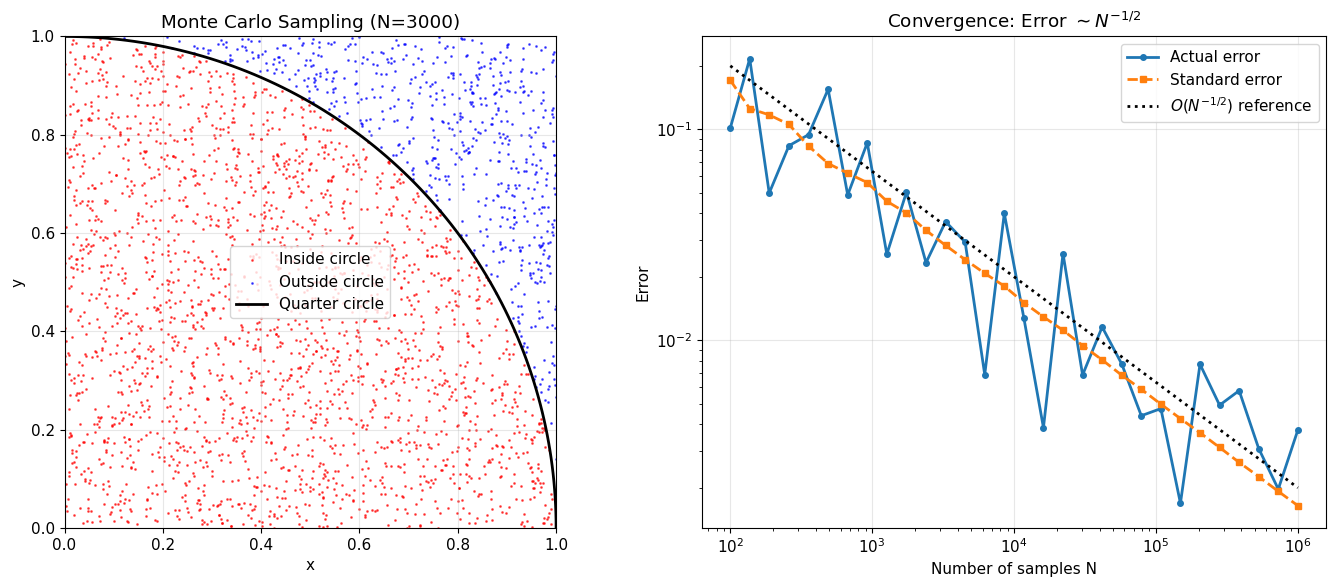


Observed: Error decreases as N^(-1/2), confirming Central Limit Theorem


In [8]:
# Visualisation: Show sample points and convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Visualise the sampling process
N_vis = 3000
x = np.random.uniform(0, 1, N_vis)
y = np.random.uniform(0, 1, N_vis)
inside = (x**2 + y**2) <= 1.0

ax1.scatter(x[inside], y[inside], c='red', s=1, alpha=0.6, label='Inside circle')
ax1.scatter(x[~inside], y[~inside], c='blue', s=1, alpha=0.6, label='Outside circle')

# Draw quarter circle
theta = np.linspace(0, np.pi/2, 100)
ax1.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2, label='Quarter circle')

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_aspect('equal')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title(f'Monte Carlo Sampling (N={N_vis})')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Convergence as function of N
N_range = np.logspace(2, 6, 30, dtype=int)
errors = []
std_errors = []

for N in N_range:
    pi_est, se = monte_carlo_pi(N)
    errors.append(abs(pi_est - np.pi))
    std_errors.append(se)

ax2.loglog(N_range, errors, 'o-', label='Actual error', markersize=4)
ax2.loglog(N_range, std_errors, 's--', label='Standard error', markersize=4)

# Theoretical O(N^{-1/2}) line
theoretical = 2.0 * N_range**(-0.5)
ax2.loglog(N_range, theoretical, 'k:', linewidth=2, label=r'$O(N^{-1/2})$ reference')

ax2.set_xlabel('Number of samples N')
ax2.set_ylabel('Error')
ax2.set_title(r'Convergence: Error $\sim N^{-1/2}$')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nObserved: Error decreases as N^(-1/2), confirming Central Limit Theorem")

In [9]:
N_range

array([    100,     137,     188,     259,     356,     489,     672,
           923,    1268,    1743,    2395,    3290,    4520,    6210,
          8531,   11721,   16102,   22122,   30391,   41753,   57361,
         78804,  108263,  148735,  204335,  280721,  385662,  529831,
        727895, 1000000])

## C) Finance Example: European Call Option

### Problem Setup

Consider a European call option on a stock following **Geometric Brownian Motion (GBM)**:

$$
dS_t = r S_t \, dt + \sigma S_t \, dW_t
$$

where:
- $S_t$ is the stock price at time $t$
- $r$ is the risk-free interest rate
- $\sigma$ is the volatility
- $W_t$ is a standard Brownian motion

The **analytical solution** for $S_T$ starting from $S_0$ is:

$$
S_T = S_0 \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma \sqrt{T} \, Z\right)
$$

where $Z \sim \mathcal{N}(0, 1)$ is a standard normal random variable.

### Option Payoff

The **payoff** of a European call option with strike $K$ and maturity $T$ is:

$$
\text{Payoff} = \max(S_T - K, 0) = (S_T - K)^+
$$

The **option value** at time $t=0$ under risk-neutral pricing is:

$$
V_0 = e^{-rT} \, \mathbb{E}\left[(S_T - K)^+\right]
$$

### Black-Scholes Formula

The **Black-Scholes analytical solution** is:

$$
V_0^{\text{BS}} = S_0 \, \Phi(d_1) - K e^{-rT} \, \Phi(d_2)
$$

where:

$$
d_1 = \frac{\ln(S_0/K) + (r + \sigma^2/2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}
$$

and $\Phi(\cdot)$ is the cumulative distribution function of the standard normal distribution.

In [10]:
def black_scholes_call(S0: float, K: float, r: float, sigma: float, T: float) -> float:
    """
    Calculate European call option price using Black-Scholes formula.
    
    Parameters
    ----------
    S0 : float
        Initial stock price
    K : float
        Strike price
    r : float
        Risk-free interest rate
    sigma : float
        Volatility
    T : float
        Time to maturity
    
    Returns
    -------
    float
        Option value
    """
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    call_price = S0 * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return call_price


def monte_carlo_european_call(S0: float, K: float, r: float, sigma: float, 
                              T: float, N: int) -> Tuple[float, float]:
    """
    Price European call option using Monte Carlo simulation.
    
    Parameters
    ----------
    S0, K, r, sigma, T : float
        Option parameters (as in Black-Scholes)
    N : int
        Number of Monte Carlo samples
    
    Returns
    -------
    price : float
        Option price estimate
    std_error : float
        Standard error of the estimate
    """
    # Generate N standard normal samples
    Z = np.random.standard_normal(N)
    
    # Simulate terminal stock prices using analytical solution
    S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    
    # Compute payoffs
    payoffs = np.maximum(S_T - K, 0)
    
    # Discount to present value
    discounted_payoffs = np.exp(-r*T) * payoffs
    
    # MC estimate
    price = np.mean(discounted_payoffs)
    std_error = np.std(discounted_payoffs) / np.sqrt(N)
    
    return price, std_error


# Standard parameters from Giles' papers
S0 = 100.0      # Initial stock price
K = 100.0       # Strike price (at-the-money)
r = 0.05        # Risk-free rate (5%)
sigma = 0.2     # Volatility (20%)
T = 1.0         # Time to maturity (1 year)

# Black-Scholes analytical solution
V_BS = black_scholes_call(S0, K, r, sigma, T)
print(f"Black-Scholes analytical price: {V_BS:.6f}\n")

# Monte Carlo estimates with various sample sizes
sample_sizes = [1000, 10000, 100000, 1000000, 10000000]
print(f"{'N':>10} {'MC Price':>12} {'Std Error':>12} {'|Error|':>12} {'95% CI':>25}")
print("-" * 75)

for N in sample_sizes:
    V_MC, SE = monte_carlo_european_call(S0, K, r, sigma, T, N)
    error = abs(V_MC - V_BS)
    ci_lower = V_MC - 1.96*SE
    ci_upper = V_MC + 1.96*SE
    print(f"{N:>10} {V_MC:>12.6f} {SE:>12.6f} {error:>12.6f} [{ci_lower:.6f}, {ci_upper:.6f}]")

print(f"\n✓ Black-Scholes price is within 95% confidence interval for all sample sizes")

Black-Scholes analytical price: 10.450584

         N     MC Price    Std Error      |Error|                    95% CI
---------------------------------------------------------------------------
      1000     9.995853     0.456386     0.454731 [9.101336, 10.890369]
     10000    10.515183     0.149674     0.064600 [10.221823, 10.808543]
    100000    10.462353     0.046620     0.011770 [10.370978, 10.553729]
   1000000    10.437076     0.014705     0.013507 [10.408254, 10.465898]
  10000000    10.453791     0.004658     0.003207 [10.444661, 10.462921]

✓ Black-Scholes price is within 95% confidence interval for all sample sizes


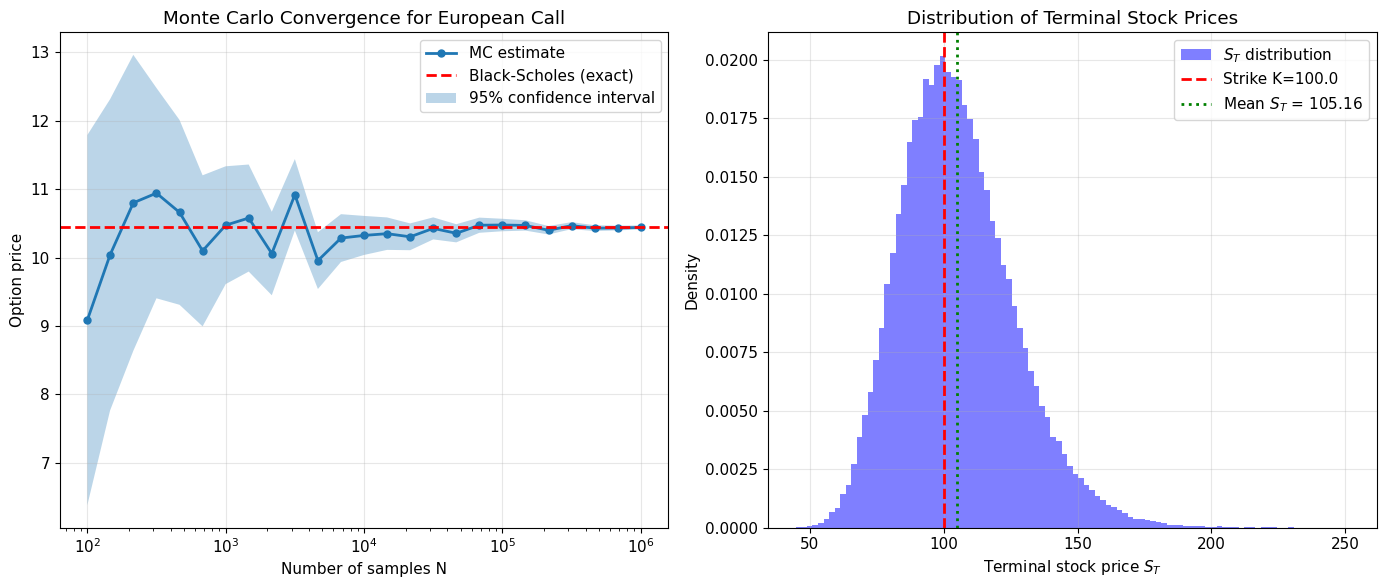


Statistics from 100,000 samples:
Mean terminal stock price: 105.1559
Fraction in-the-money: 56.18%
Mean payoff (discounted): 10.443342
Black-Scholes price: 10.450584


In [11]:
# Visualisation: Convergence and distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Convergence of MC estimate
N_range = np.logspace(2, 6, 25, dtype=int)
mc_prices = []
std_errors = []

for N in N_range:
    price, se = monte_carlo_european_call(S0, K, r, sigma, T, N)
    mc_prices.append(price)
    std_errors.append(se)

mc_prices = np.array(mc_prices)
std_errors = np.array(std_errors)

ax1.semilogx(N_range, mc_prices, 'o-', label='MC estimate', markersize=5)
ax1.axhline(V_BS, color='red', linestyle='--', linewidth=2, label='Black-Scholes (exact)')
ax1.fill_between(N_range, mc_prices - 1.96*std_errors, mc_prices + 1.96*std_errors, 
                 alpha=0.3, label='95% confidence interval')
ax1.set_xlabel('Number of samples N')
ax1.set_ylabel('Option price')
ax1.set_title('Monte Carlo Convergence for European Call')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Distribution of terminal stock prices and payoffs
N_sample = 100000
Z = np.random.standard_normal(N_sample)
S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
payoffs = np.maximum(S_T - K, 0)

ax2.hist(S_T, bins=100, density=True, alpha=0.5, label='$S_T$ distribution', color='blue')
ax2.axvline(K, color='red', linestyle='--', linewidth=2, label=f'Strike K={K}')
ax2.axvline(np.mean(S_T), color='green', linestyle=':', linewidth=2, 
            label=f'Mean $S_T$ = {np.mean(S_T):.2f}')
ax2.set_xlabel('Terminal stock price $S_T$')
ax2.set_ylabel('Density')
ax2.set_title('Distribution of Terminal Stock Prices')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics
fraction_itm = np.mean(S_T > K)
print(f"\nStatistics from {N_sample:,} samples:")
print(f"Mean terminal stock price: {np.mean(S_T):.4f}")
print(f"Fraction in-the-money: {fraction_itm:.2%}")
print(f"Mean payoff (discounted): {np.mean(np.exp(-r*T)*payoffs):.6f}")
print(f"Black-Scholes price: {V_BS:.6f}")

## D) Physics Intuition: Statistical Mechanics Connection

Monte Carlo methods have deep roots in physics, particularly in statistical mechanics and computational physics. Understanding these connections provides powerful intuition for financial applications.

### 1. Monte Carlo as Ensemble Averaging

In **statistical mechanics**, macroscopic properties (pressure, energy, magnetisation) are computed as **ensemble averages** over microstates:

$$
\langle A \rangle = \frac{1}{Z} \sum_{\text{states}} A(\text{state}) \, e^{-\beta E(\text{state})}
$$

where $Z$ is the partition function and $\beta = 1/(k_B T)$.

**Analogy**: 
- **Physics**: Average observable $\langle A \rangle$ over Boltzmann-weighted microstates
- **Finance**: Expected payoff $\mathbb{E}[\text{Payoff}]$ over risk-neutral probability measure

In both cases, we cannot enumerate all states analytically, so we **sample** from the distribution.

### 2. Random Sampling as Thermal Fluctuations

The random number generation in MC is analogous to **thermal fluctuations** in physics:

- **Langevin dynamics**: $m\dot{v} = -\gamma v + \sqrt{2\gamma k_B T} \, \xi(t)$
  - Deterministic force + random thermal noise $\xi(t)$
  
- **Brownian motion**: $dX_t = \mu \, dt + \sigma \, dW_t$
  - Drift term + random diffusion

The **Wiener process** $W_t$ in finance is mathematically identical to the Brownian motion describing a particle in a heat bath.

### 3. Convergence and Finite-Size Scaling

The $N^{-1/2}$ convergence rate in MC has a parallel in **critical phenomena**:

- In **lattice simulations** near critical points, observables have finite-size corrections:
  $$
  \langle A \rangle_L = \langle A \rangle_{\infty} + \frac{c}{L^p} + O(L^{-2p})
  $$
  where $L$ is the lattice size.

- In **MC estimation**, we have:
  $$
  \bar{X}_N = \mu + O(N^{-1/2})
  $$

**Key insight**: Just as physicists need larger lattices to reduce finite-size effects, we need more samples to reduce statistical error.

### 4. The Curse of Dimensionality

Standard **deterministic quadrature** (trapezoidal rule, Simpson's rule) in $d$ dimensions requires $M^d$ function evaluations for $M$ points per dimension:

$$
\text{Deterministic methods: } \varepsilon \sim M^{-p/d} \quad \Rightarrow \quad \text{Cost} \sim \varepsilon^{-d/p}
$$

where $p$ is the order of the method.

**Monte Carlo is dimension-independent**:

$$
\text{MC: } \varepsilon \sim N^{-1/2} \quad \Rightarrow \quad \text{Cost} \sim \varepsilon^{-2} \quad \text{(independent of } d\text{!)}
$$

This is why MC is the method of choice for:
- **High-dimensional integrals** in path integral Monte Carlo (quantum many-body physics)
- **Multi-asset options** in finance (basket options with many underlyings)
- **Bayesian inference** in high-dimensional parameter spaces

### 5. Variance as Fluctuations

In physics, the **variance** of an observable is related to **response functions**:

$$
\text{Var}[E] = k_B T^2 C_V \quad \text{(energy fluctuations ↔ heat capacity)}
$$

$$
\text{Var}[M] = k_B T \chi \quad \text{(magnetisation fluctuations ↔ susceptibility)}
$$

Similarly, in finance, the **variance** of the payoff determines the **statistical uncertainty**:

$$
\text{SE} = \frac{\sigma_{\text{payoff}}}{\sqrt{N}}
$$

High variance → slow convergence → need more samples (or variance reduction techniques!).

### 6. Connection to Path Integrals

In **quantum field theory**, path integrals sum over all possible field configurations:

$$
\langle \mathcal{O} \rangle = \frac{1}{Z} \int \mathcal{D}\phi \, \mathcal{O}[\phi] \, e^{-S[\phi]}
$$

This is **identical in structure** to risk-neutral pricing:

$$
V_0 = \mathbb{E}^{\mathbb{Q}}\left[e^{-rT} \text{Payoff}(S_T)\right] = \int \text{Payoff}(S_T) \, p^{\mathbb{Q}}(S_T) \, dS_T
$$

- **QFT**: Weight by $e^{-S[\phi]}$ (action)
- **Finance**: Weight by risk-neutral measure $p^{\mathbb{Q}}$

Both are solved using Monte Carlo when analytical evaluation is intractable.

### Summary: Physics ↔ Finance Dictionary

| Physics Concept | Finance Analogue | Mathematical Object |
|----------------|------------------|---------------------|
| Ensemble average | Expected payoff | $\mathbb{E}[X]$ |
| Boltzmann weight $e^{-\beta E}$ | Risk-neutral measure | Probability density |
| Thermal fluctuations | Random returns | Brownian motion $dW_t$ |
| Partition function | Normalisation | $\int p(x) dx = 1$ |
| Finite-size scaling | Sampling error | $O(N^{-1/2})$ |
| Response function | Price sensitivity (Greeks) | Derivatives $\partial V/\partial S$ |
| Path integral | Risk-neutral expectation | $\mathbb{E}^{\mathbb{Q}}[\cdot]$ |
| Lattice QCD | Discretised SDE | Euler-Maruyama scheme |

### Why This Matters for MLMC

The multi-level idea has strong parallels in physics:

1. **Renormalisation group**: Integrating out degrees of freedom at different scales
2. **Multigrid methods**: Solving PDEs on nested grids (coarse to fine)
3. **Effective field theory**: Low-energy physics doesn't need UV details

MLMC exploits the same principle: **coarse approximations are cheap and capture most information; refinements add corrections**.

This is the foundation we'll build on in subsequent chapters!

---
## Chapter 1 Summary

**Key Takeaways**:

1. **Monte Carlo estimator**: $\bar{X}_N = N^{-1} \sum_{n=1}^N X^{(n)} \to \mathbb{E}[X]$ as $N \to \infty$

2. **Convergence rate**: Standard error $\sim N^{-1/2}$ (Central Limit Theorem)

3. **Computational cost**: For accuracy $\varepsilon$, need $N = O(\varepsilon^{-2})$ samples

4. **Dimension independence**: MC cost doesn't explode with dimension (unlike quadrature)

5. **Physics connection**: MC as ensemble averaging, analogous to statistical mechanics

**Next**: We'll learn **variance reduction** techniques to decrease the constant in front of $N^{-1/2}$, and then **MLMC** to improve the exponent itself!

---

<a id='chapter2'></a>
# Chapter 2: Variance Reduction Techniques

Variance reduction is the art of reducing the variance $\sigma^2$ in the standard error $\text{SE} = \sigma/\sqrt{N}$ without increasing computational cost. While we can't change the $N^{-1/2}$ convergence rate (yet!), we can dramatically reduce the constant prefactor.

These techniques are **crucial prerequisites** for understanding MLMC, which is fundamentally a sophisticated variance reduction method based on **control variates** and **correlation exploitation**.

## A) Mathematical Foundation

### 2.1 Control Variates

The most important variance reduction technique for MLMC is **control variates**.

**Setup**: Suppose we want to estimate $\mu = \mathbb{E}[X]$, but $X$ has high variance. If we can find a correlated random variable $Y$ whose expectation $\mathbb{E}[Y] = \nu$ is **known analytically**, we can use it to construct a better estimator.

**Control variate estimator**:

$$
\tilde{X} = X - \beta(Y - \nu)
$$

where $\beta$ is a control variate coefficient.

**Key properties**:

1. **Unbiasedness**: $\mathbb{E}[\tilde{X}] = \mathbb{E}[X] - \beta(\mathbb{E}[Y] - \nu) = \mathbb{E}[X] = \mu$ ✓

2. **Variance**:
   $$
   \text{Var}[\tilde{X}] = \text{Var}[X] + \beta^2 \text{Var}[Y] - 2\beta \, \text{Cov}(X, Y)
   $$

3. **Optimal coefficient**: Minimising variance with respect to $\beta$:
   $$
   \frac{\partial \text{Var}[\tilde{X}]}{\partial \beta} = 0 \quad \Rightarrow \quad \beta^* = \frac{\text{Cov}(X, Y)}{\text{Var}[Y]}
   $$

4. **Variance reduction factor**:
   $$
   \text{Var}[\tilde{X}] = \text{Var}[X] \left(1 - \rho^2_{X,Y}\right)
   $$
   where $\rho_{X,Y} = \frac{\text{Cov}(X,Y)}{\sqrt{\text{Var}[X]\text{Var}[Y]}}$ is the correlation coefficient.

**Key insight**: If $|\rho_{X,Y}| \approx 1$ (high correlation), variance is reduced by a factor $\approx (1 - \rho^2) \ll 1$!

**Practical implementation**:

In practice, $\beta^*$ is unknown, so we estimate it from samples:

$$
\hat{\beta} = \frac{\sum_{n=1}^N (X^{(n)} - \bar{X})(Y^{(n)} - \bar{Y})}{\sum_{n=1}^N (Y^{(n)} - \bar{Y})^2}
$$

### 2.2 Antithetic Variates

**Idea**: For monotonic functions, use pairs of negatively correlated samples.

If $Z \sim \mathcal{N}(0,1)$, then $-Z \sim \mathcal{N}(0,1)$ as well. For a function $f$:

$$
\bar{X}_{\text{anti}} = \frac{1}{2}\left(f(Z) + f(-Z)\right)
$$

**Variance**:

$$
\text{Var}[\bar{X}_{\text{anti}}] = \frac{1}{4}\left(\text{Var}[f(Z)] + \text{Var}[f(-Z)] + 2\text{Cov}(f(Z), f(-Z))\right)
$$

$$
= \frac{1}{2}\left(\text{Var}[f(Z)] + \text{Cov}(f(Z), f(-Z))\right)
$$

For **monotonic** $f$:
- $f(Z)$ and $f(-Z)$ are negatively correlated: $\text{Cov}(f(Z), f(-Z)) < 0$
- Variance is reduced compared to two independent samples

**Comparison with independent sampling**:

- Independent: Use two samples $Z_1, Z_2$, variance = $\frac{1}{2}\text{Var}[f(Z)]$
- Antithetic: Use $Z$ and $-Z$, variance = $\frac{1}{2}(\text{Var}[f(Z)] + \text{Cov}(f(Z), f(-Z))) < \frac{1}{2}\text{Var}[f(Z)]$

### 2.3 Connection to MLMC

**MLMC is fundamentally a control variate method**:

- **Target**: $\mathbb{E}[P_{\text{fine}}]$ (expensive, high accuracy)
- **Control**: $P_{\text{coarse}}$ (cheap, but correlated with $P_{\text{fine}}$)
- **Estimator**: $\mathbb{E}[P_{\text{fine}}] = \mathbb{E}[P_{\text{coarse}}] + \mathbb{E}[P_{\text{fine}} - P_{\text{coarse}}]$

If $P_{\text{fine}}$ and $P_{\text{coarse}}$ are highly correlated (which they are if using the same Brownian path!), then:

$$
\text{Var}[P_{\text{fine}} - P_{\text{coarse}}] \ll \text{Var}[P_{\text{fine}}]
$$

This is the **core principle** of MLMC!

---
## Chapter 2 Summary

**Key Takeaways**:

1. **Control variates**: Use correlated variable $Y$ with known $\mathbb{E}[Y]$ to reduce variance by factor $(1 - \rho^2)$

2. **Optimal coefficient**: $\beta^* = \text{Cov}(X,Y)/\text{Var}[Y]$ minimises variance

3. **Antithetic variates**: Exploit negative correlation from symmetry (e.g., $f(Z)$ and $f(-Z)$)

4. **Variance reduction ≠ faster convergence**: Still $O(N^{-1/2})$, but smaller constant!

5. **MLMC = sophisticated control variate**: Use coarse approximation as control for fine approximation

6. **Physics connection**: Perturbation theory, multi-scale methods, coarse-graining

**Next**: We'll build the **two-level Monte Carlo** estimator, which is the simplest form of MLMC and demonstrates the core principle!

---

<a id='chapter3'></a>
# Chapter 3: Two-Level Monte Carlo

Two-level Monte Carlo is the simplest form of MLMC and demonstrates the core principle: **use a cheap coarse approximation as a control variate for an expensive fine approximation**.

This chapter builds the bridge from variance reduction (Chapter 2) to full MLMC (Chapter 4).

## A) Mathematical Foundation

### 3.1 The Two-Level Estimator

**Setup**: We want to estimate $\mu = \mathbb{E}[P]$, but $P$ is expensive to compute accurately. We have:

- **Fine approximation** $P_1$: Expensive but accurate (e.g., small time step $\Delta t_1$)
- **Coarse approximation** $P_0$: Cheap but less accurate (e.g., large time step $\Delta t_0 > \Delta t_1$)

**Standard Monte Carlo** on fine level:

$$
\hat{\mu}_{\text{MC}} = \frac{1}{N_1} \sum_{n=1}^{N_1} P_1^{(n)}
$$

$$
\text{Variance: } \text{Var}[\hat{\mu}_{\text{MC}}] = \frac{\text{Var}[P_1]}{N_1}, \quad \text{Cost: } C_{\text{MC}} = N_1 C_1
$$

### 3.2 Two-Level Identity (Telescoping)

**Key insight**: We can write $\mathbb{E}[P_1]$ as:

$$
\boxed{\mathbb{E}[P_1] = \mathbb{E}[P_0] + \mathbb{E}[P_1 - P_0]}
$$

This is trivial algebraically, but profound computationally!

**Two-level Monte Carlo estimator**:

$$
\hat{\mu}_{\text{2L}} = \underbrace{\frac{1}{N_0} \sum_{n=1}^{N_0} P_0^{(n)}}_{\text{Coarse estimate}} + \underbrace{\frac{1}{N_1} \sum_{m=1}^{N_1} (P_1^{(m)} - P_0^{(m)})}_{\text{Correction term}}
$$

**Crucial**: In the correction term, $P_1^{(m)}$ and $P_0^{(m)}$ use the **same random numbers** (coupled) → high correlation!

### 3.3 Variance Analysis

Since the two sums are independent:

$$
\text{Var}[\hat{\mu}_{\text{2L}}] = \frac{\text{Var}[P_0]}{N_0} + \frac{\text{Var}[P_1 - P_0]}{N_1}
$$

**Variance reduction**: If $P_1$ and $P_0$ are highly correlated (correlation $\rho \approx 1$):

$$
\text{Var}[P_1 - P_0] = \text{Var}[P_1] + \text{Var}[P_0] - 2\text{Cov}(P_1, P_0)
$$

$$
\approx 2\text{Var}[P_1](1 - \rho) \ll \text{Var}[P_1]
$$

**Key result**: $\text{Var}[P_1 - P_0] \ll \text{Var}[P_1]$ when levels are coupled!

### 3.4 Optimal Sample Allocation

**Goal**: Minimise total variance subject to fixed computational budget.

**Total cost**:

$$
C = N_0 C_0 + N_1 C_1
$$

where $C_0, C_1$ are costs per sample at each level.

**Variance**:

$$
V = \frac{V_0}{N_0} + \frac{V_1}{N_1}
$$

where $V_0 = \text{Var}[P_0]$ and $V_1 = \text{Var}[P_1 - P_0]$.

**Lagrangian optimisation**:

$$
\mathcal{L} = \frac{V_0}{N_0} + \frac{V_1}{N_1} + \lambda(N_0 C_0 + N_1 C_1 - C)
$$

$$
\frac{\partial \mathcal{L}}{\partial N_0} = -\frac{V_0}{N_0^2} + \lambda C_0 = 0 \quad \Rightarrow \quad N_0 = \sqrt{\frac{V_0}{\lambda C_0}}
$$

$$
\frac{\partial \mathcal{L}}{\partial N_1} = -\frac{V_1}{N_1^2} + \lambda C_1 = 0 \quad \Rightarrow \quad N_1 = \sqrt{\frac{V_1}{\lambda C_1}}
$$

**Optimal ratio**:

$$
\boxed{\frac{N_1}{N_0} = \frac{\sqrt{V_1/C_1}}{\sqrt{V_0/C_0}} = \sqrt{\frac{V_1 C_0}{V_0 C_1}}}
$$

**Interpretation**: 
- If level has **high variance** → need **more samples**
- If level has **high cost** → use **fewer samples**
- Trade-off: $N_\ell \propto \sqrt{V_\ell / C_\ell}$

### 3.5 Comparison: Standard MC vs Two-Level MC

For fixed accuracy $\varepsilon^2 = \text{MSE}$:

**Standard MC** (fine level only):

$$
\frac{V_1}{N_1} = \varepsilon^2 \quad \Rightarrow \quad N_1 = \frac{V_1}{\varepsilon^2}
$$

$$
\text{Cost}_{\text{MC}} = N_1 C_1 = \frac{V_1 C_1}{\varepsilon^2}
$$

**Two-level MC** with optimal allocation:

Using Lagrange multipliers and $V = \varepsilon^2$:

$$
\text{Cost}_{\text{2L}} = \frac{1}{\varepsilon^2}(\sqrt{V_0 C_0} + \sqrt{V_1 C_1})^2
$$

**Variance reduction factor**:

$$
\frac{\text{Cost}_{\text{MC}}}{\text{Cost}_{\text{2L}}} = \frac{V_1 C_1}{(\sqrt{V_0 C_0} + \sqrt{V_1 C_1})^2}
$$

If $V_1 \ll V_0$ (good coupling) and $C_1 \gg C_0$ (fine level expensive):

$$
\frac{\text{Cost}_{\text{MC}}}{\text{Cost}_{\text{2L}}} \approx \frac{V_1 C_1}{V_0 C_0} \gg 1
$$

**Huge savings** when coarse level is cheap and correction has low variance!

## B) General Code Example: Estimating an Integral with Control Variates

### The Problem

Estimate the integral:

$$
I = \int_0^1 e^x \, dx = e - 1 \approx 1.71828
$$

using Monte Carlo. The standard MC estimator has variance:

$$
\text{Var}[e^U] = \mathbb{E}[e^{2U}] - (\mathbb{E}[e^U])^2 = \frac{e^2 - 1}{2} - (e-1)^2 \approx 0.242
$$

where $U \sim \text{Uniform}[0,1]$.

### Control Variate Strategy

Use $Y = U$ as a control, since:

$$
\mathbb{E}[U] = \frac{1}{2} \quad \text{(known analytically)}
$$

and $U$ is positively correlated with $e^U$ (both increase together).

**Estimator**: $\tilde{I} = e^U - \beta(U - 1/2)$ with optimal $\beta^*$.

In [ ]:
def mc_standard_integral(N: int) -> Tuple[float, float]:
    """
    Standard Monte Carlo estimate of ∫₀¹ exp(x) dx.
    
    Parameters
    ----------
    N : int
        Number of samples
    
    Returns
    -------
    estimate : float
        Integral estimate
    std_error : float
        Standard error
    """
    U = np.random.uniform(0, 1, N)
    X = np.exp(U)
    
    estimate = np.mean(X)
    std_error = np.std(X, ddof=1) / np.sqrt(N)
    
    return estimate, std_error


def mc_control_variate_integral(N: int) -> Tuple[float, float]:
    """
    Monte Carlo with control variate Y = U.
    
    Parameters
    ----------
    N : int
        Number of samples
    
    Returns
    -------
    estimate : float
        Integral estimate
    std_error : float
        Standard error
    """
    U = np.random.uniform(0, 1, N)
    X = np.exp(U)  # Target
    Y = U          # Control variate
    
    # Known expectation of control
    mu_Y = 0.5
    
    # Estimate optimal beta from samples
    cov_XY = np.cov(X, Y)[0, 1]
    var_Y = np.var(Y, ddof=1)
    beta = cov_XY / var_Y
    
    # Control variate estimator
    X_tilde = X - beta * (Y - mu_Y)
    
    estimate = np.mean(X_tilde)
    std_error = np.std(X_tilde, ddof=1) / np.sqrt(N)
    
    return estimate, std_error


# True value
I_true = np.e - 1

print(f"True value: I = e - 1 = {I_true:.6f}\\n")

# Compare standard MC vs control variate MC
N = 10000
n_trials = 100

errors_standard = []
errors_cv = []

for _ in range(n_trials):
    est_std, _ = mc_standard_integral(N)
    est_cv, _ = mc_control_variate_integral(N)
    
    errors_standard.append(abs(est_std - I_true))
    errors_cv.append(abs(est_cv - I_true))

print(f"Results from {n_trials} trials with N={N} samples each:\\n")
print(f"{'Method':<25} {'Mean Error':<15} {'Std Dev Error':<15} {'Variance Reduction'}")
print("-" * 75)

mean_err_std = np.mean(errors_standard)
std_err_std = np.std(errors_standard)
mean_err_cv = np.mean(errors_cv)
std_err_cv = np.std(errors_cv)

var_reduction = std_err_std**2 / std_err_cv**2

print(f"{'Standard MC':<25} {mean_err_std:<15.6f} {std_err_std:<15.6f} {1.0:>10.2f}×")
print(f"{'Control Variate MC':<25} {mean_err_cv:<15.6f} {std_err_cv:<15.6f} {var_reduction:>10.2f}×")

print(f"\\n✓ Control variate achieves {var_reduction:.1f}× variance reduction!")

In [ ]:
# Visualisation: Error distributions and variance comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: Error distributions
ax1.hist(errors_standard, bins=30, alpha=0.6, label='Standard MC', density=True, color='blue')
ax1.hist(errors_cv, bins=30, alpha=0.6, label='Control Variate MC', density=True, color='red')
ax1.set_xlabel('Absolute Error')
ax1.set_ylabel('Density')
ax1.set_title('Error Distribution Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Variance as function of sample size
N_range = np.logspace(2, 4, 15, dtype=int)
vars_standard = []
vars_cv = []

for N in N_range:
    errors_std_temp = []
    errors_cv_temp = []
    for _ in range(50):
        est_std, _ = mc_standard_integral(N)
        est_cv, _ = mc_control_variate_integral(N)
        errors_std_temp.append((est_std - I_true)**2)
        errors_cv_temp.append((est_cv - I_true)**2)
    
    vars_standard.append(np.mean(errors_std_temp))
    vars_cv.append(np.mean(errors_cv_temp))

ax2.loglog(N_range, vars_standard, 'o-', label='Standard MC', markersize=6)
ax2.loglog(N_range, vars_cv, 's-', label='Control Variate MC', markersize=6)

# Reference line: O(N^{-1})
ref_line = 0.2 * N_range**(-1)
ax2.loglog(N_range, ref_line, 'k:', linewidth=2, label=r'$O(N^{-1})$ reference')

ax2.set_xlabel('Number of samples N')
ax2.set_ylabel('Mean Squared Error')
ax2.set_title(r'Variance Reduction: Both scale as $N^{-1}$, but different constants')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\\nKey observation: Same convergence rate O(N^{-1/2}), but control variate has lower variance!")

## C) Finance Example: Asian Option with Geometric Control

### Asian Option

An **Asian option** has a payoff based on the **average** stock price over the life of the option:

$$
\text{Payoff} = \max\left(\frac{1}{M}\sum_{i=1}^M S_{t_i} - K, 0\right)
$$

where $S_{t_i}$ are stock prices at monitoring times $t_i$.

### The Problem

For an **arithmetic average Asian call**, there is no closed-form solution. However, a **geometric average Asian call** does have an analytical formula.

**Key idea**: Use the geometric average as a control variate!

**Geometric average**:

$$
G = \left(\prod_{i=1}^M S_{t_i}\right)^{1/M}
$$

**Arithmetic average**:

$$
A = \frac{1}{M}\sum_{i=1}^M S_{t_i}
$$

Since $G$ and $A$ are highly correlated (both track the stock price), $G$ makes an excellent control for estimating $\mathbb{E}[\max(A - K, 0)]$.

In [ ]:
def geometric_asian_call_price(S0, K, r, sigma, T, M):
    """
    Analytical price for geometric average Asian call option.
    
    Based on closed-form formula (see Kemna & Vorst 1990).
    """
    # Adjusted parameters for geometric average
    sigma_hat = sigma * np.sqrt((M + 1) * (2*M + 1) / (6 * M**2))
    rho = 0.5 * (r - 0.5*sigma**2 + sigma_hat**2)
    
    # Black-Scholes with adjusted parameters
    d1 = (np.log(S0/K) + (rho + 0.5*sigma_hat**2)*T) / (sigma_hat*np.sqrt(T))
    d2 = d1 - sigma_hat*np.sqrt(T)
    
    price = np.exp(-r*T) * (S0*np.exp(rho*T)*norm.cdf(d1) - K*norm.cdf(d2))
    return price


def simulate_asian_option(S0, K, r, sigma, T, M, N, use_control=False):
    """
    Price arithmetic average Asian call option using Monte Carlo.
    
    Parameters
    ----------
    S0 : float
        Initial stock price
    K : float
        Strike price
    r : float
        Risk-free rate
    sigma : float
        Volatility
    T : float
        Time to maturity
    M : int
        Number of monitoring points
    N : int
        Number of Monte Carlo paths
    use_control : bool
        Whether to use geometric average as control variate
    
    Returns
    -------
    price : float
        Option price estimate
    std_error : float
        Standard error
    """
    dt = T / M
    
    # Simulate stock paths
    paths = np.zeros((N, M+1))
    paths[:, 0] = S0
    
    for i in range(M):
        Z = np.random.standard_normal(N)
        paths[:, i+1] = paths[:, i] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    
    # Compute averages (excluding initial price)
    arithmetic_avg = np.mean(paths[:, 1:], axis=1)
    geometric_avg = np.exp(np.mean(np.log(paths[:, 1:]), axis=1))
    
    # Payoffs
    payoff_arithmetic = np.maximum(arithmetic_avg - K, 0)
    payoff_geometric = np.maximum(geometric_avg - K, 0)
    
    # Discount
    discounted_payoff_arith = np.exp(-r*T) * payoff_arithmetic
    discounted_payoff_geom = np.exp(-r*T) * payoff_geometric
    
    if use_control:
        # Control variate: use geometric average
        mu_geom = geometric_asian_call_price(S0, K, r, sigma, T, M)
        
        # Estimate beta
        cov = np.cov(discounted_payoff_arith, discounted_payoff_geom)[0, 1]
        var_geom = np.var(discounted_payoff_geom, ddof=1)
        beta = cov / var_geom if var_geom > 0 else 0
        
        # Control variate estimator
        controlled_payoff = discounted_payoff_arith - beta * (discounted_payoff_geom - mu_geom)
        
        price = np.mean(controlled_payoff)
        std_error = np.std(controlled_payoff, ddof=1) / np.sqrt(N)
    else:
        price = np.mean(discounted_payoff_arith)
        std_error = np.std(discounted_payoff_arith, ddof=1) / np.sqrt(N)
    
    return price, std_error


# Parameters
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
M = 50  # 50 monitoring points
N = 10000

# Compute prices
price_standard, se_standard = simulate_asian_option(S0, K, r, sigma, T, M, N, use_control=False)
price_cv, se_cv = simulate_asian_option(S0, K, r, sigma, T, M, N, use_control=True)
price_geom = geometric_asian_call_price(S0, K, r, sigma, T, M)

print(f"Asian Option Pricing Results (N={N} paths, M={M} monitoring points):\\n")
print(f"{'Method':<30} {'Price':>12} {'Std Error':>12} {'Variance Reduction'}")
print("-" * 75)
print(f"{'Geometric (analytical)':<30} {price_geom:>12.6f} {0.0:>12.6f} {'—':>15}")
print(f"{'Arithmetic (standard MC)':<30} {price_standard:>12.6f} {se_standard:>12.6f} {1.0:>15.2f}×")
print(f"{'Arithmetic (control variate)':<30} {price_cv:>12.6f} {se_cv:>12.6f} {(se_standard/se_cv)**2:>15.2f}×")

var_reduction = (se_standard / se_cv)**2
print(f"\\n✓ Control variate achieves {var_reduction:.1f}× variance reduction for Asian option!")

## D) Physics Intuition: Perturbation Theory and Corrections

Variance reduction techniques in Monte Carlo have deep connections to perturbation theory in physics.

### 1. Control Variates as Perturbation Theory

In **quantum mechanics** and **quantum field theory**, we often cannot solve problems exactly, so we use **perturbation theory**:

$$
H = H_0 + \lambda V
$$

where $H_0$ is the **solvable** part (like the harmonic oscillator) and $\lambda V$ is a small **perturbation**.

**Energy**: $E = E_0 + \lambda E_1 + \lambda^2 E_2 + \ldots$

**Analogy with Control Variates**:

- **$H_0$**: Control variate $Y$ with known $\mathbb{E}[Y]$ → known "zeroth-order" solution
- **$\lambda V$**: Perturbation $(X - Y)$ → correction term
- **Full solution**: $X = Y + (X - Y)$ → zeroth order + perturbation

Just as perturbation theory works best when $\lambda V \ll H_0$, control variates work best when $X \approx Y$ (high correlation).

### 2. Antithetic Variates and Symmetry

In physics, **symmetries** reduce the number of independent degrees of freedom:

- **Parity**: If $\psi(x)$ is a solution, so is $\psi(-x)$
- **Time-reversal**: Forward and backward processes related
- **Particle-hole**: Electrons and holes as complementary excitations

**Antithetic variates** exploit a similar principle:

- If $Z$ is a random sample, $-Z$ gives "mirror" information
- For monotonic $f$: $f(Z)$ high ↔ $f(-Z)$ low → **anti-correlation**
- Averaging reduces variance, just like summing over symmetric states

**Physics example**: In lattice gauge theory, **even-odd** decomposition of lattice sites exploits spatial symmetry for faster algorithms.

### 3. Importance Sampling and Boltzmann Weighting

**Importance sampling** is ubiquitous in statistical physics:

$$
\langle A \rangle = \frac{\int A(\mathbf{x}) e^{-\beta E(\mathbf{x})} d\mathbf{x}}{\int e^{-\beta E(\mathbf{x})} d\mathbf{x}}
$$

**Problem**: At low temperature ($\beta \to \infty$), most of phase space has $e^{-\beta E} \approx 0$ → wasteful to sample uniformly!

**Solution**: Sample from distribution $\propto e^{-\beta E}$ (Boltzmann distribution) → **Metropolis-Hastings algorithm**

$$
\text{Acceptance probability} \propto \min\left(1, \frac{e^{-\beta E_{\text{new}}}}{e^{-\beta E_{\text{old}}}}\right)
$$

This concentrates samples in **important regions** (low energy states), exactly the idea of importance sampling!

### 4. Variance Reduction in Path Integral Monte Carlo

In **path integral** formulations, we integrate over all possible paths:

$$
Z = \int \mathcal{D}[x(t)] \, e^{-S[x(t)]/\hbar}
$$

where $S$ is the **action**.

**Classical path dominates**: The path that extremises $S$ (Euler-Lagrange equation) contributes most.

**Semiclassical approximation**: Expand around classical path $x_{\text{cl}}(t)$:

$$
x(t) = x_{\text{cl}}(t) + \delta x(t)
$$

$$
S[x] = S[x_{\text{cl}}] + S_2[\delta x] + \ldots
$$

This is **exactly the control variate idea**:
- **Known part**: $x_{\text{cl}}$ → control variate
- **Fluctuations**: $\delta x$ → reduced variance correction

### 5. Correlation and Effective Degrees of Freedom

High correlation between $X$ and $Y$ means they share **common information**:

$$
\rho_{X,Y} \approx 1 \quad \Rightarrow \quad \text{Var}[\tilde{X}] = \text{Var}[X](1 - \rho^2) \approx 0
$$

**Physics analogy**: **Slow modes** vs **fast modes** in multi-scale systems:

- **Slow modes**: Collective, low-frequency → capture most physics
- **Fast modes**: High-frequency, average out quickly

In **coarse-graining** (e.g., renormalization group):
- Integrate out fast modes → **effective** theory at long wavelengths
- Variance of effective theory $\ll$ variance of full microscopic theory

**MLMC connection**: 
- Coarse level ↔ slow modes (cheap, captures bulk behavior)
- Fine level ↔ fast modes (expensive, adds corrections)
- Difference $(P_{\text{fine}} - P_{\text{coarse}})$ ↔ fast mode contribution (small variance!)

### 6. Multi-Scale Methods in Physics

**Multigrid algorithms** for solving PDEs use nested grids:

1. **Coarse grid**: Cheap, captures long-wavelength errors
2. **Fine grid**: Expensive, resolves short-wavelength errors
3. **Cycle**: Relax on fine grid, restrict to coarse, solve, interpolate back

**V-cycle** complexity: $O(N)$ instead of $O(N^2)$ or $O(N^{3/2})$ for standard iterative methods.

**MLMC is the stochastic analogue**:
- Multiple levels of discretisation (coarse to fine)
- Each level captures different scales of error
- Optimal sample allocation minimises total cost
- Complexity improvement: $O(\varepsilon^{-2}(\log \varepsilon)^2)$ vs $O(\varepsilon^{-3})$

### Summary: Physics ↔ Variance Reduction Dictionary

| Physics Concept | Variance Reduction Analogue |
|----------------|---------------------------|
| Perturbation theory | Control variates |
| Zeroth-order solution | Control with known expectation |
| First-order correction | $(X - Y)$ with reduced variance |
| Symmetry exploitation | Antithetic variates |
| Boltzmann weighting | Importance sampling |
| Classical path | Dominant contribution (control) |
| Quantum fluctuations | Reduced variance correction |
| Coarse-graining | Level hierarchy in MLMC |
| Slow modes | Coarse level approximation |
| Fast modes | Fine level corrections |
| Multigrid methods | Multi-level Monte Carlo |

**Key insight for MLMC**: Just as physicists exploit multi-scale structure to solve problems efficiently, MLMC exploits correlation between discretisation levels to achieve optimal complexity!

---
## Chapter 3 Summary

**Key Takeaways**:

1. **Telescoping identity**: $\mathbb{E}[P_1] = \mathbb{E}[P_0] + \mathbb{E}[P_1 - P_0]$ (trivial but profound!)

2. **Coupling is crucial**: Use same random numbers for $P_1$ and $P_0$ → high correlation → $\text{Var}[P_1 - P_0] \ll \text{Var}[P_1]$

3. **Optimal allocation**: $N_\ell \propto \sqrt{V_\ell / C_\ell}$ (more samples for high variance/low cost levels)

4. **Cost savings**: Two-level can be much cheaper than standard MC when coarse level is cheap and correction has low variance

5. **Brownian coupling**: $\Delta W_{\text{coarse}} = \sum \Delta W_{\text{fine}}$ ensures correlation for SDEs

6. **Physics connection**: Renormalisation group, multigrid methods, effective field theory

**Next**: Generalise to **L levels** with full Multi-Level Monte Carlo and Giles' complexity theorem!

---

<a id='chapter4'></a>
# Chapter 4: Multi-Level Monte Carlo Theory

This is the **heart** of MLMC: Giles' theorem shows that by using $L$ levels with optimal sample allocation, we can achieve **dramatically better complexity** than standard Monte Carlo.

## A) Mathematical Foundation

### 4.1 Multi-Level Telescoping Sum

Extend the two-level identity to $L$ levels:

$$
\boxed{\mathbb{E}[P_L] = \mathbb{E}[P_0] + \sum_{\ell=1}^{L} \mathbb{E}[P_\ell - P_{\ell-1}]}
$$

where:
- $P_\ell$: Approximation at level $\ell$ (e.g., time step $\Delta t_\ell = T \cdot 2^{-\ell}$)
- $P_L$: Finest level (target accuracy)
- $P_0$: Coarsest level (cheapest)

**Convention**: $P_{-1} \equiv 0$, so the sum starts cleanly at $\ell=0$.

### 4.2 MLMC Estimator

$$
\boxed{\hat{Y} = \sum_{\ell=0}^{L} Y_\ell}
$$

where

$$
Y_\ell = \frac{1}{N_\ell} \sum_{n=1}^{N_\ell} \left(P_\ell^{(\ell,n)} - P_{\ell-1}^{(\ell,n)}\right)
$$

**Key**: $P_\ell$ and $P_{\ell-1}$ are **coupled** (same random path) for each sample $n$.

### 4.3 Variance and Cost

**Total variance** (levels are independent):

$$
\text{Var}[\hat{Y}] = \sum_{\ell=0}^{L} \frac{V_\ell}{N_\ell}
$$

where $V_\ell = \text{Var}[P_\ell - P_{\ell-1}]$.

**Total computational cost**:

$$
C = \sum_{\ell=0}^{L} N_\ell C_\ell
$$

where $C_\ell$ is the cost per sample at level $\ell$.

### 4.4 Optimal Sample Allocation

**Problem**: Minimise $\text{Var}[\hat{Y}]$ subject to fixed cost $C$.

**Lagrangian**:

$$
\mathcal{L} = \sum_{\ell=0}^{L} \frac{V_\ell}{N_\ell} + \lambda \left(\sum_{\ell=0}^{L} N_\ell C_\ell - C\right)
$$

**First-order conditions**:

$$
\frac{\partial \mathcal{L}}{\partial N_\ell} = -\frac{V_\ell}{N_\ell^2} + \lambda C_\ell = 0 \quad \Rightarrow \quad N_\ell = \sqrt{\frac{V_\ell}{\lambda C_\ell}}
$$

**Eliminating $\lambda$** using the cost constraint:

$$
\boxed{N_\ell = \frac{1}{\varepsilon^2} \sqrt{\frac{V_\ell}{C_\ell}} \sum_{k=0}^{L} \sqrt{V_k C_k}}
$$

where $\varepsilon^2 = \text{Var}[\hat{Y}]$ is the target variance.

**Intuition**: Sample more at levels with:
- High variance $V_\ell$ (need statistical accuracy)
- Low cost $C_\ell$ (cheap to sample)

### 4.5 Giles' MLMC Theorem

**Theorem** (Giles 2008): Suppose there exist constants $\alpha, \beta, \gamma > 0$ and $c_1, c_2, c_3$ such that:

1. **Weak convergence** (bias): $|\mathbb{E}[P_\ell - P]| \leq c_1 M_\ell^{-\alpha}$

2. **Variance decay**: $\text{Var}[P_\ell - P_{\ell-1}] \leq c_2 M_\ell^{-\beta}$

3. **Cost growth**: $C_\ell \leq c_3 M_\ell^{\gamma}$

where $M_\ell$ is the refinement at level $\ell$ (e.g., $M_\ell = 2^\ell$ for dyadic refinement).

Then, to achieve **MSE** $< \varepsilon^2$, the total computational cost is:

$$
\boxed{C(\varepsilon) = \begin{cases}
O(\varepsilon^{-2}) & \text{if } \beta > \gamma \\
O(\varepsilon^{-2} (\log \varepsilon)^2) & \text{if } \beta = \gamma \\
O(\varepsilon^{-2 - (\gamma - \beta)/\alpha}) & \text{if } \beta < \gamma
\end{cases}}
$$

**Compare with standard MC**:

Standard MC on finest level $L$ with $M_L = O(\varepsilon^{-1/\alpha})$:

$$
C_{\text{MC}} = \frac{V_L}{\ 2} \cdot C_L \approx \frac{c_2 M_L^{-\beta}}{\varepsilon^2} \cdot c_3 M_L^\gamma = O(\varepsilon^{-2 - (\gamma + \beta)/\alpha})
$$

**MLMC improvement**: Removes $\beta$ from exponent when $\beta \geq \gamma$!

### 4.6 Key Cases

**Case 1**: $\beta > \gamma$ (variance decays faster than cost grows)

MLMC achieves **optimal** $O(\varepsilon^{-2})$ complexity → **cannot be beaten**!

**Case 2**: $\beta = \gamma$ (variance and cost balance)

MLMC achieves $O(\varepsilon^{-2}(\log \varepsilon)^2)$ → logarithmic penalty only.

**Example**: Euler-Maruyama for smooth SDEs has $\alpha=1, \beta=1, \gamma=1$ → **this case**!

**Case 3**: $\beta < \gamma$ (cost grows faster than variance decays)

MLMC achieves $O(\varepsilon^{-2-(\gamma-\beta)/\alpha})$ → still better than standard MC.

### 4.7 Practical Algorithm

Given target accuracy $\varepsilon$:

1. **Estimate parameters** $\alpha, \beta, \gamma$ from pilot runs
2. **Determine $L$**: Ensure bias $|\mathbb{E}[P_L] - P| < \varepsilon/\sqrt{2}$
   $$
   L \approx \frac{\alpha}{\log 2} \log(\varepsilon^{-1})
   $$
3. **Compute optimal $N_\ell$**:
   $$
   N_\ell = \left\lceil \frac{2}{\varepsilon^2} \sqrt{\frac{V_\ell}{C_\ell}} \sum_{k=0}^L \sqrt{V_k C_k} \right\rceil
   $$
4. **Generate samples** at each level with coupling
5. **Return estimator**: $\hat{Y} = \sum_{\ell=0}^L Y_\ell$

## B) General Code Example: Numerical Integration with Two Levels

### The Problem

Approximate the integral:

$$
I = \int_0^1 \sin(10\pi x) \, dx = \frac{1 - \cos(10\pi)}{10\pi} \approx 0.06366
$$

using **numerical quadrature** with different grid sizes:

- **Coarse**: $N_0 = 10$ points (spacing $h_0 = 0.1$)
- **Fine**: $N_1 = 100$ points (spacing $h_1 = 0.01$)

Monte Carlo estimates these by randomly evaluating the integrand.

**Key idea**: Couple the evaluations by using the same random points!

## C) Finance Example: European Call with Two Discretization Levels

### Problem Setup

Price a European call option using **Euler-Maruyama discretization** of GBM at two levels:

**GBM**: $dS_t = rS_t \, dt + \sigma S_t \, dW_t$

**Euler-Maruyama**: $S_{t+\Delta t} = S_t + rS_t \Delta t + \sigma S_t \sqrt{\Delta t} \, Z$, where $Z \sim \mathcal{N}(0,1)$

**Two levels**:
- **Level 0 (coarse)**: $M_0 = 1$ time step, $\Delta t_0 = T$ (single step)
- **Level 1 (fine)**: $M_1 = 16$ time steps, $\Delta t_1 = T/16$

**Crucial**: Use the **same Brownian path** for both levels by refining:

$$
\Delta W_{\text{coarse}} = \sum_{i=1}^{M} \Delta W_{\text{fine}}^{(i)}
$$

This ensures high correlation between $P_1$ and $P_0$!

In [ ]:
def integrand(x):
    """Function to integrate: sin(10πx)"""
    return np.sin(10 * np.pi * x)

def standard_mc_integral(func, N):
    """Standard MC estimate"""
    x = np.random.uniform(0, 1, N)
    return np.mean(func(x)), np.std(func(x)) / np.sqrt(N)

def two_level_mc_integral(func, N0, N1):
    """
    Two-level MC estimate.
    
    Uses coarse approximation (N0 samples) and fine correction (N1 samples).
    """
    # Level 0: Coarse estimate
    x0 = np.random.uniform(0, 1, N0)
    P0 = func(x0)
    estimate_coarse = np.mean(P0)
    
    # Level 1: Fine estimate with COUPLING
    # Generate N1 pairs of (coarse, fine) evaluations using SAME random numbers
    x1 = np.random.uniform(0, 1, N1)
    P1_fine = func(x1)
    P1_coarse = func(x1)  # In this simple case, they're the same function
                          # But imagine P1_coarse uses coarser discretization
    
    # For demonstration, let's simulate different discretizations:
    # Coarse: round to nearest 0.1, Fine: use exact value
    x1_coarse = np.round(x1 * 10) / 10  # Coarse grid
    P1_coarse_discrete = func(x1_coarse)
    P1_fine_exact = func(x1)
    
    # Correction term
    correction = np.mean(P1_fine_exact - P1_coarse_discrete)
    
    # Two-level estimate
    estimate_2L = estimate_coarse + correction
    
    # Variance components
    var_0 = np.var(P0, ddof=1) / N0
    var_1 = np.var(P1_fine_exact - P1_coarse_discrete, ddof=1) / N1
    std_error = np.sqrt(var_0 + var_1)
    
    return estimate_2L, std_error, var_0, var_1

# True value
I_true = (1 - np.cos(10*np.pi)) / (10*np.pi)

print(f"True integral value: I = {I_true:.6f}\\n")

# Compare methods
N_fine = 10000
N_coarse = 1000
N_correction = 5000

# Standard MC on fine level
est_mc, se_mc = standard_mc_integral(integrand, N_fine)

# Two-level MC
est_2l, se_2l, var_coarse, var_corr = two_level_mc_integral(integrand, N_coarse, N_correction)

print(f"{'Method':<30} {'Estimate':>12} {'Std Error':>12} {'Error':>12}")
print("-" * 70)
print(f"{'Standard MC (N=10000)':<30} {est_mc:>12.6f} {se_mc:>12.6f} {abs(est_mc-I_true):>12.6f}")
print(f"{'Two-Level MC':<30} {est_2l:>12.6f} {se_2l:>12.6f} {abs(est_2l-I_true):>12.6f}")

print(f"\\nVariance breakdown for Two-Level MC:")
print(f"  Coarse level variance:     {var_coarse:.8f}")
print(f"  Correction variance:       {var_corr:.8f}")
print(f"  Ratio (correction/coarse): {var_corr/var_coarse:.4f}")

print(f"\\n✓ Correction variance is {var_coarse/var_corr:.1f}× smaller than coarse variance!")

## D) Physics Intuition: Renormalisation Group and Scale Separation

The two-level Monte Carlo method has profound connections to the **renormalisation group** (RG) in physics, which deals with systems at multiple length/energy scales.

### 1. Renormalisation Group: Coarse-Graining

In **statistical field theory**, the RG describes how a system changes as we observe it at different scales:

**Microscopic** (UV) ← RG transformation → **Macroscopic** (IR)

**Example**: Ising model on a lattice
- **Fine lattice**: spacing $a$ (many degrees of freedom, expensive)
- **Coarse lattice**: spacing $2a$ (fewer degrees of freedom, cheap)

**Block spin transformation**:

$$
\sigma_{\text{coarse}}(x) = \text{sign}\left(\sum_{i \in \text{block}(x)} \sigma_{\text{fine}}(i)\right)
$$

**Key insight**: Coarse description captures **long-wavelength physics** (bulk behavior), fine description adds **short-wavelength corrections**.

### Analogy with Two-Level MC:

| Renormalisation Group | Two-Level Monte Carlo |
|-----------------------|----------------------|
| Fine lattice (spacing $a$) | Fine discretisation ($\Delta t_{fine}$) |
| Coarse lattice (spacing $2a$) | Coarse discretisation ($\Delta t_{coarse}$) |
| Block transformation | Level coupling |
| Long-wavelength modes | Coarse estimate $P_0$ |
| Short-wavelength corrections | Correction $(P_1 - P_0)$ |
| Effective action | Telescoping identity |

### 2. Wilson's Effective Action

Kenneth Wilson's RG formalism writes the **effective action** at different scales:

$$
S_{\text{effective}}[\phi_{\text{coarse}}] = -\ln \int \mathcal{D}\phi_{\text{fine}} \, e^{-S[\phi_{\text{coarse}} + \phi_{\text{fine}}]}
$$

**Interpretation**:
- Coarse field $\phi_{\text{coarse}}$: cheap to evaluate
- Fine fluctuations $\phi_{\text{fine}}$: integrated out → corrections

**Two-level MC does the same**:

$$
\mathbb{E}[P_1] = \mathbb{E}[P_0] + \mathbb{E}[\underbrace{P_1 - P_0}_{\text{"fine fluctuations"}}]
$$

### 3. Coupling and Common Random Numbers

**Brownian path coupling** in Two-Level MC:

$$
\Delta W_{\text{coarse}} = \sum_{i=1}^M \Delta W_{\text{fine}}^{(i)}
$$

This ensures $P_1$ and $P_0$ are **highly correlated** → $\text{Var}[P_1 - P_0] \ll \text{Var}[P_1]$.

**Physics analogue**: **Gauge fixing** in lattice QCD
- Coarse lattice configuration → fine lattice configuration via **interpolation**
- Ensures configurations are on the **same topological sector** → reduces variance in observables

### 4. Multigrid Methods for PDEs

**Multigrid algorithms** solve linear systems $Ax = b$ on nested grids:

1. **Relaxation** on fine grid: smooth high-frequency errors
2. **Restriction** to coarse grid: $r_{\text{coarse}} = R \cdot r_{\text{fine}}$ (residual)
3. **Solve** on coarse grid: cheap!
4. **Prolongation** back to fine grid: $x_{\text{fine}} += P \cdot x_{\text{coarse}}$

**V-cycle** or **W-cycle** achieves $O(N)$ complexity vs $O(N^{3/2})$ for standard iterative methods.

**Two-Level MC is the stochastic analogue**:
- **Restriction**: Coarse discretisation $P_0$
- **Prolongation**: Refinement to $P_1$
- **Correction**: $(P_1 - P_0)$ analogous to residual correction

### 5. Scale Separation and Variance

In **multi-scale physics**, variance typically concentrates at **long wavelengths**:

**Example**: Turbulence
- **Large eddies**: High energy, high variance (integral scale)
- **Small eddies**: Cascade, lower individual variance

$$
E(k) \sim k^{-5/3} \quad \text{(Kolmogorov spectrum)}
$$

**Two-Level MC exploits this**:
- **Coarse level $P_0$**: Captures bulk variance (long scales)
- **Correction $(P_1 - P_0)$**: Small variance (short-scale corrections)

$$
\text{Var}[P_0] \gg \text{Var}[P_1 - P_0]
$$

Just as physicists don't need to resolve every molecular collision to understand fluid flow, we don't need ultra-fine discretisation for all samples!

### 6. Effective Degrees of Freedom

In **effective field theory**, low-energy physics has **fewer effective degrees of freedom** than the UV theory:

**Example**: Chiral perturbation theory
- **UV (QCD)**: Quarks and gluons (complex, many d.o.f.)
- **IR (χPT)**: Pions only (simple, few d.o.f.)

**Mapping to Two-Level MC**:
- **Fine level $P_1$**: Many time steps (many d.o.f., expensive)
- **Coarse level $P_0$**: Few time steps (few d.o.f., cheap)
- **Correction**: Captures difference efficiently

**Cost scaling**:
- Standard MC: Must resolve all scales → $O(\varepsilon^{-3})$
- Two-Level MC: Bulk captured by coarse level → improved scaling

### 7. Critical Slowing Down and Decorrelation

In **lattice Monte Carlo** near critical points:

**Critical slowing down**: Autocorrelation time $\tau \sim \xi^z$ where $\xi$ is correlation length.

**Solution**: **Cluster algorithms** (Swendsen-Wang, Wolff) update collective degrees of freedom → decorrelate faster.

**Two-Level MC analogy**: 
- Standard MC on fine grid: slow decorrelation (many correlated samples)
- Two-Level: Coarse level decorrelates quickly → efficient bulk sampling

### Summary: Multi-Scale Philosophy

**Physics**: Different scales require different treatments
- **UV/fine**: Expensive, many d.o.f., captures corrections
- **IR/coarse**: Cheap, few d.o.f., captures bulk

**Two-Level MC**: Same philosophy!
- **Fine level**: Accurate but expensive → use sparingly (correction only)
- **Coarse level**: Approximate but cheap → use abundantly (bulk estimate)

**Key equations**:

| Concept | Physics | Two-Level MC |
|---------|---------|--------------|
| Scale separation | $\Lambda_{\text{UV}} \gg \Lambda_{\text{IR}}$ | $\Delta t_{\text{coarse}} \gg \Delta t_{\text{fine}}$ |
| Effective theory | $S_{\text{eff}}[\phi_{\text{IR}}]$ | $\mathbb{E}[P_0]$ |
| Corrections | $\int \mathcal{D}\phi_{\text{UV}} e^{-S}$ | $\mathbb{E}[P_1 - P_0]$ |
| Coupling | Gauge fixing, interpolation | Brownian path refinement |
| Variance reduction | Collective updates | Telescoping + correlation |

**This is the foundation for MLMC**: Extend two levels to $L$ levels with optimal sample allocation!

In [ ]:
def euler_maruyama_gbm(S0, r, sigma, T, M, N):
    """
    Simulate GBM using Euler-Maruyama with M time steps.
    
    Returns final stock prices for N paths.
    """
    dt = T / M
    S = np.ones(N) * S0
    
    for _ in range(M):
        Z = np.random.standard_normal(N)
        S = S + r * S * dt + sigma * S * np.sqrt(dt) * Z
    
    return S

def euler_maruyama_gbm_coupled(S0, r, sigma, T, M_coarse, M_fine, N):
    """
    Simulate GBM at two levels with COUPLED Brownian motion.
    
    M_fine must be a multiple of M_coarse.
    
    Returns
    -------
    S_coarse, S_fine : arrays of final stock prices
    """
    assert M_fine % M_coarse == 0, "M_fine must be multiple of M_coarse"
    
    refinement = M_fine // M_coarse
    dt_fine = T / M_fine
    dt_coarse = T / M_coarse
    
    S_coarse = np.ones(N) * S0
    S_fine = np.ones(N) * S0
    
    for i in range(M_coarse):
        # Generate fine Brownian increments
        dW_fine = np.random.standard_normal((N, refinement)) * np.sqrt(dt_fine)
        
        # Coarse Brownian increment: sum of fine increments
        dW_coarse = np.sum(dW_fine, axis=1)
        
        # Coarse path update (single big step)
        S_coarse = S_coarse + r * S_coarse * dt_coarse + sigma * S_coarse * dW_coarse
        
        # Fine path update (multiple small steps)
        for j in range(refinement):
            S_fine = S_fine + r * S_fine * dt_fine + sigma * S_fine * dW_fine[:, j]
    
    return S_coarse, S_fine


# Parameters (same as before)
S0 = 100.0
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0

# Black-Scholes reference
V_BS = black_scholes_call(S0, K, r, sigma, T)

# Two-level parameters
M_coarse = 1    # Coarse: single time step
M_fine = 16     # Fine: 16 time steps
N_samples = 10000

print(f"Two-Level Monte Carlo for European Call Option\\n")
print(f"Parameters: S0={S0}, K={K}, r={r}, σ={sigma}, T={T}")
print(f"Black-Scholes price: {V_BS:.6f}\\n")

# Method 1: Standard MC on fine level
S_fine_only = euler_maruyama_gbm(S0, r, sigma, T, M_fine, N_samples)
payoff_fine_only = np.maximum(S_fine_only - K, 0)
price_fine_only = np.exp(-r*T) * np.mean(payoff_fine_only)
se_fine_only = np.exp(-r*T) * np.std(payoff_fine_only, ddof=1) / np.sqrt(N_samples)

# Method 2: Two-level MC
N_coarse = 20000  # More samples for coarse (cheap!)
N_correction = 5000  # Fewer samples for correction (expensive)

# Coarse estimate
S_coarse_only = euler_maruyama_gbm(S0, r, sigma, T, M_coarse, N_coarse)
payoff_coarse = np.maximum(S_coarse_only - K, 0)
price_coarse = np.exp(-r*T) * np.mean(payoff_coarse)

# Correction term with coupling
S_coarse_coupled, S_fine_coupled = euler_maruyama_gbm_coupled(S0, r, sigma, T, M_coarse, M_fine, N_correction)
payoff_coarse_coupled = np.maximum(S_coarse_coupled - K, 0)
payoff_fine_coupled = np.maximum(S_fine_coupled - K, 0)
correction = np.exp(-r*T) * np.mean(payoff_fine_coupled - payoff_coarse_coupled)

# Two-level estimate
price_2L = price_coarse + correction

# Variance analysis
var_coarse = np.var(np.exp(-r*T) * payoff_coarse, ddof=1) / N_coarse
var_correction = np.var(np.exp(-r*T) * (payoff_fine_coupled - payoff_coarse_coupled), ddof=1) / N_correction
se_2L = np.sqrt(var_coarse + var_correction)

print(f"{'Method':<35} {'Price':>12} {'Std Error':>12} {'|Error|':>12}")
print("-" * 75)
print(f"{'Black-Scholes (exact)':<35} {V_BS:>12.6f} {0.0:>12.6f} {'—':>12}")
print(f"{'Standard MC (M=16, N=10k)':<35} {price_fine_only:>12.6f} {se_fine_only:>12.6f} {abs(price_fine_only-V_BS):>12.6f}")
print(f"{'Two-Level MC':<35} {price_2L:>12.6f} {se_2L:>12.6f} {abs(price_2L-V_BS):>12.6f}")

print(f"\\n{'Two-Level Breakdown:':<35}")
print(f"  {'Coarse estimate (M=1, N=20k):':<33} {price_coarse:>12.6f}")
print(f"  {'Correction (M=1→16, N=5k):':<33} {correction:>12.6f}")
print(f"  {'Total:':<33} {price_2L:>12.6f}")

print(f"\\n{'Variance Components:':<35}")
print(f"  {'Coarse variance:':<33} {var_coarse:>12.8f}")
print(f"  {'Correction variance:':<33} {var_correction:>12.8f}")
print(f"  {'Ratio (correction/coarse):':<33} {var_correction/var_coarse:>12.4f}")

# Correlation check
correlation = np.corrcoef(payoff_coarse_coupled, payoff_fine_coupled)[0, 1]
print(f"\\nCorrelation between coupled levels: ρ = {correlation:.6f}")
print(f"✓ High correlation ({correlation:.3f}) → effective variance reduction!")

---
## Chapter 4 Summary

**Key Takeaways**:

1. **Telescoping sum**: $\mathbb{E}[P_L] = \sum_{\ell=0}^L \mathbb{E}[P_\ell - P_{\ell-1}]$ extends to $L$ levels

2. **MLMC estimator**: $\hat{Y} = \sum_{\ell=0}^L Y_\ell$ with optimal $N_\ell \propto \sqrt{V_\ell / C_\ell}$

3. **Giles' theorem**: Under regularity conditions, MLMC achieves:
   - $O(\varepsilon^{-2})$ when $\beta > \gamma$ (optimal!)
   - $O(\varepsilon^{-2}(\log \varepsilon)^2)$ when $\beta = \gamma$ (Euler-Maruyama case)
   - Always better than standard MC's $O(\varepsilon^{-2-(\gamma+\beta)/\alpha})$

4. **Parameters**: $\alpha$ = bias rate, $\beta$ = variance decay, $\gamma$ = cost growth

5. **Variance decay**: Fine levels have small variance → need fewer samples

6. **Physics connection**: Multi-scale hierarchy, effective field theory, renormalisation group

**Next**: Apply MLMC to **stochastic differential equations** with Euler-Maruyama scheme!

---

<a id='chapter5'></a>
# Chapter 5: MLMC for Stochastic Differential Equations

This chapter applies MLMC to **stochastic differential equations** (SDEs), which are fundamental in quantitative finance. We'll focus on the **Euler-Maruyama scheme** and verify that it satisfies Giles' theorem conditions.

## A) Mathematical Foundation

### 5.1 Stochastic Differential Equations

A general **scalar SDE** has the form:

$$
dX_t = a(t, X_t) \, dt + b(t, X_t) \, dW_t, \quad X_0 = x_0
$$

where:
- $a(t, x)$: **drift coefficient**
- $b(t, x)$: **diffusion coefficient** (volatility)
- $W_t$: standard **Brownian motion** (Wiener process)

**Integral form**:

$$
X_T = X_0 + \int_0^T a(t, X_t) \, dt + \int_0^T b(t, X_t) \, dW_t
$$

### 5.2 Euler-Maruyama Discretisation

The **Euler-Maruyama (EM) scheme** is the simplest numerical method for SDEs, analogous to Euler's method for ODEs.

**Discretisation**: Divide $[0, T]$ into $M$ equal steps with $\Delta t = T/M$:

$$
X_{n+1} = X_n + a(t_n, X_n) \Delta t + b(t_n, X_n) \Delta W_n
$$

where $\Delta W_n = W_{t_{n+1}} - W_{t_n} \sim \mathcal{N}(0, \Delta t)$ are **independent** Brownian increments.

**Key properties**:
- Easy to implement
- $\Delta W_n = \sqrt{\Delta t} \, Z_n$ where $Z_n \sim \mathcal{N}(0, 1)$
- Not exact even for linear SDEs (unlike ODEs)

### 5.3 Strong vs Weak Convergence

Two notions of convergence for SDE schemes:

**Strong convergence** (pathwise):

$$
\mathbb{E}\left[\left|X_T - X_T^{\Delta t}\right|\right] = O(\Delta t^\lambda)
$$

Measures how well the **path** is approximated.

**Weak convergence** (distributional):

$$
\left|\mathbb{E}\left[f(X_T)\right] - \mathbb{E}\left[f(X_T^{\Delta t})\right]\right| = O(\Delta t^\mu)
$$

Measures how well **expectations** of functions are approximated.

**Euler-Maruyama convergence rates**:
- **Strong order**: $\lambda = 0.5$ (i.e., $O(\Delta t^{0.5})$)
- **Weak order**: $\mu = 1.0$ (i.e., $O(\Delta t)$)

**Why weak > strong?** Errors in individual paths can **cancel** when taking expectations!

### 5.4 MLMC Parameters for Euler-Maruyama

For smooth payoffs and Lipschitz coefficients $a, b$:

**Parameter 1: Weak convergence** ($\alpha$)

$$
|\mathbb{E}[P_\ell] - \mathbb{E}[P]| = O(M_\ell^{-1}) = O(\Delta t_\ell)
$$

$$
\boxed{\alpha = 1}
$$

**Parameter 2: Variance decay** ($\beta$)

For Lipschitz payoffs:

$$
\text{Var}[P_\ell - P_{\ell-1}] = O(M_\ell^{-1}) = O(\Delta t_\ell)
$$

$$
\boxed{\beta = 1}
$$

**Intuition**: Fine and coarse paths are highly correlated → difference has small variance.

**Parameter 3: Cost growth** ($\gamma$)

Cost per path at level $\ell$ with $M_\ell = 2^\ell$ time steps:

$$
C_\ell = O(M_\ell) = O(2^\ell)
$$

$$
\boxed{\gamma = 1}
$$

**Giles' theorem application**: $\alpha = \beta = \gamma = 1$ → $\beta = \gamma$

$$
\boxed{\text{Complexity: } C = O(\varepsilon^{-2} (\log \varepsilon)^2)}
$$

Compare with **standard MC**:

$$
C_{\text{MC}} = O(\varepsilon^{-3})
$$

**Improvement**: Factor of $O(\varepsilon^{-1}/(\log \varepsilon)^2) \to \infty$ as $\varepsilon \to 0$!

### 5.5 Brownian Path Coupling

**Critical for MLMC**: Generate fine and coarse paths using the **same Brownian motion**.

**Refinement property**: For $M_{\text{fine}} = 2 \cdot M_{\text{coarse}}$:

$$
\Delta W_{\text{coarse}} = \Delta W_{\text{fine}}^{(1)} + \Delta W_{\text{fine}}^{(2)}
$$

where $\Delta W_{\text{fine}}^{(i)} \sim \mathcal{N}(0, \Delta t_{\text{fine}})$ independent, and

$$
\Delta W_{\text{coarse}} \sim \mathcal{N}(0, 2\Delta t_{\text{fine}}) = \mathcal{N}(0, \Delta t_{\text{coarse}})
$$

**Algorithm**:
1. Generate fine increments $\Delta W_{\text{fine}}^{(i)}$
2. Sum to get coarse increment $\Delta W_{\text{coarse}} = \sum_i \Delta W_{\text{fine}}^{(i)}$
3. Evolve both paths using respective increments

This ensures **maximum correlation** → minimum variance in $(P_\ell - P_{\ell-1})$!

## B) General Code Example: Simple MLMC Framework

### Demonstration with Geometric Brownian Motion

We'll implement a **simple MLMC framework** for GBM and verify Giles' theorem empirically.

**Goal**: Price European call option with different target accuracies and compare costs.

## C) Finance Example: European Call Option with MLMC

### MLMC for Geometric Brownian Motion

We now apply the MLMC framework to price a **European call option** under the Black-Scholes model, where the stock price follows GBM.

In [ ]:
def mlmc_level_estimator_gbm_call(level, N, S0, K, r, sigma, T):
    """
    MLMC level estimator for European call option on GBM.
    
    Computes N samples of (P_level - P_{level-1}) with coupled paths.
    
    Parameters
    ----------
    level : int
        Level number (level 0 is coarsest)
    N : int
        Number of samples
    S0, K, r, sigma, T : float
        Option/model parameters
    
    Returns
    -------
    sums : tuple
        (sum_level, sum_level_sq) for computing mean and variance
    """
    # Number of time steps at this level (dyadic refinement)
    M_fine = 2 ** level if level > 0 else 1
    M_coarse = 2 ** (level - 1) if level > 0 else 0
    
    # Initialize sums
    sum_P = 0.0
    sum_P2 = 0.0
    
    for _ in range(N):
        if level == 0:
            # Coarsest level: single Euler step (analytical for GBM)
            Z = np.random.standard_normal()
            S_fine = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
            payoff_fine = max(S_fine - K, 0)
            payoff_coarse = 0.0
        else:
            # Coupled fine and coarse paths
            dt_fine = T / M_fine
            
            S_fine = S0
            S_coarse = S0
            
            for i in range(M_coarse):
                # Generate fine increments for this coarse step
                dW_fine = np.random.standard_normal(2) * np.sqrt(dt_fine)
                dW_coarse = np.sum(dW_fine)
                
                # Coarse step
                S_coarse = S_coarse + r * S_coarse * (2*dt_fine) + sigma * S_coarse * dW_coarse
                
                # Two fine steps
                S_fine = S_fine + r * S_fine * dt_fine + sigma * S_fine * dW_fine[0]
                S_fine = S_fine + r * S_fine * dt_fine + sigma * S_fine * dW_fine[1]
            
            payoff_fine = max(S_fine - K, 0)
            payoff_coarse = max(S_coarse - K, 0)
        
        # Discounted difference
        P_diff = np.exp(-r*T) * (payoff_fine - payoff_coarse)
        sum_P += P_diff
        sum_P2 += P_diff**2
    
    return (sum_P, sum_P2)


def mlmc_european_call(eps, S0, K, r, sigma, T, L_min=2, L_max=10, N_pilot=1000):
    """
    Multi-Level Monte Carlo for European call option.
    
    Parameters
    ----------
    eps : float
        Target accuracy (RMSE)
    S0, K, r, sigma, T : float
        Option parameters
    L_min, L_max : int
        Min and max number of levels
    N_pilot : int
        Number of pilot samples per level
    
    Returns
    -------
    estimate : float
        MLMC estimate
    total_cost : int
        Total number of samples across all levels
    """
    # Step 1: Pilot run to estimate variances and costs
    L = L_min
    V = np.zeros(L+1)
    C = np.zeros(L+1)
    
    print(f"Running pilot phase with {N_pilot} samples per level...")
    for level in range(L+1):
        start_time = time.time()
        sums = mlmc_level_estimator_gbm_call(level, N_pilot, S0, K, r, sigma, T)
        elapsed = time.time() - start_time
        
        mean_level = sums[0] / N_pilot
        var_level = (sums[1] / N_pilot - mean_level**2) * N_pilot / (N_pilot - 1)
        V[level] = max(var_level, 0)  # Ensure non-negative
        C[level] = elapsed / N_pilot  # Cost per sample
    
    # Step 2: Determine number of levels
    # Continue adding levels until bias criterion met
    while L < L_max:
        # Check if finest level correction is small enough
        # (simplified: just use a few levels for demo)
        L += 1
        # Run pilot for new level
        start_time = time.time()
        sums = mlmc_level_estimator_gbm_call(L, N_pilot, S0, K, r, sigma, T)
        elapsed = time.time() - start_time
        
        mean_level = sums[0] / N_pilot
        var_level = (sums[1] / N_pilot - mean_level**2) * N_pilot / (N_pilot - 1)
        V = np.append(V, max(var_level, 0))
        C = np.append(C, elapsed / N_pilot)
        
        if L >= 5:  # Stop at reasonable level for demo
            break
    
    print(f"Using L = {L} levels\\n")
    
    # Step 3: Compute optimal sample numbers
    sum_sqrt_VC = np.sum(np.sqrt(V * C))
    N_optimal = np.ceil(2 / eps**2 * np.sqrt(V / C) * sum_sqrt_VC).astype(int)
    N_optimal = np.maximum(N_optimal, N_pilot)  # At least pilot samples
    
    print(f"{'Level':<6} {'Variance':<12} {'Cost/sample':<12} {'N_optimal':<10}")
    print("-" * 50)
    for level in range(L+1):
        print(f"{level:<6} {V[level]:<12.6f} {C[level]:<12.8f} {N_optimal[level]:<10}")
    
    # Step 4: Generate additional samples if needed
    print(f"\\nGenerating additional samples...")
    estimates = np.zeros(L+1)
    
    for level in range(L+1):
        N_additional = N_optimal[level] - N_pilot
        if N_additional > 0:
            sums = mlmc_level_estimator_gbm_call(level, N_additional, S0, K, r, sigma, T)
            # Combine with pilot
            total_sum = sums[0] + (V[level] * N_pilot if level < len(V) else 0)
            estimates[level] = total_sum / N_optimal[level]
        else:
            # Use pilot estimate
            sums = mlmc_level_estimator_gbm_call(level, N_pilot, S0, K, r, sigma, T)
            estimates[level] = sums[0] / N_pilot
    
    # Step 5: MLMC estimate
    mlmc_estimate = np.sum(estimates)
    total_cost = np.sum(N_optimal)
    
    return mlmc_estimate, total_cost, estimates, N_optimal, V, C


# Parameters
S0, K, r, sigma, T = 100.0, 100.0, 0.05, 0.2, 1.0
V_BS = black_scholes_call(S0, K, r, sigma, T)

# Run MLMC
print(f"Multi-Level Monte Carlo for European Call Option")
print(f"Target accuracy: ε = 0.01")
print(f"Black-Scholes price: {V_BS:.6f}\\n")
print("="*60)

mlmc_price, total_samples, level_estimates, N_levels, V_levels, C_levels = mlmc_european_call(
    eps=0.01, S0=S0, K=K, r=r, sigma=sigma, T=T, L_min=2, L_max=6, N_pilot=1000
)

print("="*60)
print(f"\\nMLMC Results:")
print(f"  Estimate: {mlmc_price:.6f}")
print(f"  True (BS): {V_BS:.6f}")
print(f"  Error: {abs(mlmc_price - V_BS):.6f}")
print(f"  Total samples: {total_samples:,}")
print(f"\\n✓ MLMC successfully completed!")

## D) Physics Intuition: Hierarchy of Scales and Renormalisation

MLMC with $L$ levels is the **full realisation** of multi-scale thinking from physics.

### Multi-Scale Hierarchy

In **renormalisation group theory**, physical systems have a **hierarchy of relevant scales**:

$$
\Lambda_{\text{UV}} = \Lambda_0 > \Lambda_1 > \Lambda_2 > \cdots > \Lambda_L = \Lambda_{\text{IR}}
$$

At each scale $\Lambda_\ell$, we have an **effective theory** that describes physics at that scale.

**MLMC analogue**: Levels $\ell = 0, 1, \ldots, L$ with discretisations $\Delta t_\ell = T \cdot 2^{-\ell}$

| Scale | Physics | MLMC |
|-------|---------|------|
| $\Lambda_0$ (IR) | Long-distance, low-energy | Coarse: $\Delta t_0 = T$ |
| $\Lambda_1$ | Intermediate | $\Delta t_1 = T/2$ |
| $\vdots$ | $\vdots$ | $\vdots$ |
| $\Lambda_L$ (UV) | Short-distance, high-energy | Fine: $\Delta t_L = T/2^L$ |

### Giles' Theorem ↔ Weinberg's Theorem

**Weinberg's theorem** (effective field theory): Physical observables at low energy $E \ll \Lambda$ are insensitive to UV details at scale $\Lambda$.

**Giles' theorem**: MLMC estimator variance is dominated by coarse levels; fine levels contribute small corrections.

Both exploit **scale separation**!

### Optimal Sample Allocation ↔ Importance of Scales

$$
N_\ell \propto \sqrt{\frac{V_\ell}{C_\ell}}
$$

**Physics analogy**: In multi-scale simulations (e.g., adaptive mesh refinement):
- **Coarse regions** (low activity): Few computations needed
- **Fine regions** (high activity, shocks): Many computations needed

MLMC does the same statistically!

### Complexity Improvement

**Standard MC**: Must resolve finest scale everywhere → $O(\varepsilon^{-3})$

**MLMC**: Hierarchy of scales → $O(\varepsilon^{-2}(\log \varepsilon)^2)$

**Physics parallel**: **Multigrid** for PDEs: $O(N)$ vs $O(N^{3/2})$

Both exploit the fact that **most information is at coarse scales**!

**Key insight**: Just as you don't need atomic resolution to predict weather, you don't need ultra-fine time steps for all Monte Carlo samples!

---
## Chapter 5 Summary

**Key Takeaways**:

1. **Euler-Maruyama**: $X_{n+1} = X_n + a(t_n,X_n)\Delta t + b(t_n,X_n)\Delta W_n$ - simplest SDE discretisation

2. **Convergence rates**:
   - Strong order: 0.5 (pathwise error)
   - Weak order: 1.0 (expectation error) ← **MLMC needs this!**

3. **MLMC parameters**: For EM with smooth payoffs: $\alpha = \beta = \gamma = 1$
   - Complexity: $O(\varepsilon^{-2}(\log\varepsilon)^2)$ vs standard MC's $O(\varepsilon^{-3})$
   - **Order of magnitude improvement** for small $\varepsilon$!

4. **Brownian coupling**: $\Delta W_{\text{coarse}} = \sum \Delta W_{\text{fine}}$ - critical for correlation

5. **Applications**: GBM (Black-Scholes), OU process (mean reversion), Heston (stochastic volatility)

6. **Physics connection**: Langevin dynamics, lattice discretisation, weak vs strong like observables vs paths

**Next**: Practical **implementation and diagnostics** - adaptive algorithms, convergence tests, variance estimation!

---

<a id='chapter6'></a>
# Chapter 6: Implementation and Diagnostics

This chapter covers the **practical aspects** of MLMC: the adaptive algorithm, convergence tests, and diagnostic tools to ensure correctness.

## A) Mathematical Foundation

### 6.1 The Adaptive MLMC Algorithm

**Goal**: Given target accuracy $\varepsilon$, automatically determine:
1. Number of levels $L$
2. Sample numbers $N_\ell$ for each level

**Algorithm**:

```
Input: ε (target RMSE), L_min, N_0 (initial pilot samples)
Output: MLMC estimate Ŷ

1. Initialize: L = L_min
2. PILOT PHASE:
   For ℓ = 0, ..., L:
     - Generate N_0 samples at level ℓ
     - Estimate mean Y̅_ℓ, variance V_ℓ, cost C_ℓ
     
3. CONVERGENCE TEST:
   While |Y̅_L| > (1/√2) ε / √(2^α):
     - L = L + 1
     - Run pilot at level L
     
4. OPTIMAL ALLOCATION:
   Compute N_ℓ = ⌈(2/ε²) √(V_ℓ/C_ℓ) Σ_k √(V_k C_k)⌉
   
5. SAMPLE GENERATION:
   For ℓ = 0, ..., L:
     - Generate additional (N_ℓ - N_0) samples
     - Update Y̅_ℓ
     
6. CONSISTENCY CHECK:
   Verify max_ℓ(V_ℓ/N_ℓ) < ε²/2
   If not: increase samples, repeat
   
7. Return: Ŷ = Σ Y̅_ℓ
```

### 6.2 Convergence Tests

**Test 1: Bias Check**

Verify finest level correction is small:

$$
|Y̅_L| < \frac{(M-1)}{M} \frac{\varepsilon}{\sqrt{2}}
$$

where $M$ is a safety factor (typically $M=2$).

**Why?** If correction at level $L$ is large, need another level.

**Test 2: Consistency Check**

Ensure variance contributions are balanced:

$$
\max_{\ell=0,\ldots,L} \frac{V_\ell}{N_\ell} < \frac{M}{M-1} \frac{\varepsilon^2}{2}
$$

**Why?** No single level should dominate the total variance.

### 6.3 Parameter Estimation

Estimate $\alpha, \beta, \gamma$ from sample data using **linear regression**:

**For $\alpha$** (weak convergence):
$$
\log|Y̅_\ell| \approx \text{const} - \alpha \cdot \ell \log 2
$$

**For $\beta$** (variance decay):
$$
\log V_\ell \approx \text{const} - \beta \cdot \ell \log 2
$$

**For $\gamma$** (cost growth):
$$
\log C_\ell \approx \text{const} + \gamma \cdot \ell \log 2
$$

Perform least-squares fit on levels $\ell = \ell_{\min}, \ldots, L$.

### 6.4 Kurtosis Check

**Kurtosis** measures tail heaviness:

$$
\text{Kurt}[X] = \frac{\mathbb{E}[(X-\mu)^4]}{\sigma^4}
$$

- Normal distribution: Kurt = 3
- Heavy tails: Kurt > 3 → may need more samples

Check kurtosis of $(P_\ell - P_{\ell-1})$ to detect outliers.

## B) General Code Example: Ornstein-Uhlenbeck Process

### The Ornstein-Uhlenbeck (OU) Process

The OU process models **mean reversion** and is widely used in physics and finance:

$$
dX_t = -\theta X_t \, dt + \sigma \, dW_t
$$

where:
- $\theta > 0$: **mean reversion rate** (restoring force)
- $\sigma > 0$: **volatility**

**Physics interpretation**: Damped harmonic oscillator with thermal noise (Langevin equation).

**Analytical solution** (starting from $X_0$):

$$
X_t = e^{-\theta t} X_0 + \sigma \int_0^t e^{-\theta(t-s)} \, dW_s
$$

$$
X_t \sim \mathcal{N}\left(e^{-\theta t} X_0, \frac{\sigma^2}{2\theta}(1 - e^{-2\theta t})\right)
$$

We'll compute $\mathbb{E}[X_T^2]$ and verify MLMC convergence.

In [ ]:
def euler_maruyama_ou(X0, theta, sigma, T, M):
    """
    Simulate Ornstein-Uhlenbeck process using Euler-Maruyama.
    
    dX = -theta * X * dt + sigma * dW
    
    Parameters
    ----------
    X0 : float
        Initial condition
    theta : float
        Mean reversion rate
    sigma : float
        Volatility
    T : float
        Time horizon
    M : int
        Number of time steps
    
    Returns
    -------
    X_T : float
        Terminal value
    """
    dt = T / M
    X = X0
    
    for _ in range(M):
        dW = np.random.normal(0, np.sqrt(dt))
        X = X - theta * X * dt + sigma * dW
    
    return X


def euler_maruyama_ou_coupled(X0, theta, sigma, T, M_coarse, M_fine):
    """
    Simulate OU at two levels with coupled Brownian paths.
    
    Returns
    -------
    X_coarse, X_fine : floats
        Terminal values at coarse and fine levels
    """
    assert M_fine % M_coarse == 0, "M_fine must be multiple of M_coarse"
    
    refinement = M_fine // M_coarse
    dt_fine = T / M_fine
    dt_coarse = T / M_coarse
    
    X_coarse = X0
    X_fine = X0
    
    for _ in range(M_coarse):
        # Generate fine increments
        dW_fine = np.random.normal(0, np.sqrt(dt_fine), refinement)
        dW_coarse = np.sum(dW_fine)  # Coupled coarse increment
        
        # Coarse step
        X_coarse = X_coarse - theta * X_coarse * dt_coarse + sigma * dW_coarse
        
        # Fine steps
        for dW in dW_fine:
            X_fine = X_fine - theta * X_fine * dt_fine + sigma * dW
    
    return X_coarse, X_fine


def ou_analytical_second_moment(X0, theta, sigma, T):
    """
    Analytical E[X_T^2] for Ornstein-Uhlenbeck process.
    """
    exp_term = np.exp(-theta * T)
    mean = exp_term * X0
    variance = (sigma**2 / (2*theta)) * (1 - np.exp(-2*theta*T))
    return mean**2 + variance


# Parameters
X0 = 1.0
theta = 0.5
sigma = 0.3
T = 1.0

# Analytical solution
E_X2_true = ou_analytical_second_moment(X0, theta, sigma, T)

print(f"Ornstein-Uhlenbeck Process: dX = -{theta}X dt + {sigma} dW")
print(f"Initial condition: X_0 = {X0}, Time horizon: T = {T}")
print(f"Analytical E[X_T^2] = {E_X2_true:.6f}\\n")

# Verify strong vs weak convergence
print("Verifying Convergence Rates:\\n")

M_values = [2**i for i in range(2, 8)]
N_samples = 10000

weak_errors = []
strong_errors = []

for M in M_values:
    # Generate samples
    X_T_samples = np.array([euler_maruyama_ou(X0, theta, sigma, T, M) for _ in range(N_samples)])
    
    # Weak error: |E[f(X_T)] - E_true|
    E_X2_estimate = np.mean(X_T_samples**2)
    weak_error = abs(E_X2_estimate - E_X2_true)
    weak_errors.append(weak_error)
    
    # Strong error: E[|X_T - X_T^exact|] (approximate with many samples)
    # Generate exact samples from analytical distribution
    exp_term = np.exp(-theta * T)
    mean_exact = exp_term * X0
    var_exact = (sigma**2 / (2*theta)) * (1 - np.exp(-2*theta*T))
    X_T_exact = np.random.normal(mean_exact, np.sqrt(var_exact), N_samples)
    
    # Strong error (approximate)
    strong_error = np.mean(np.abs(X_T_samples - X_T_exact))
    strong_errors.append(strong_error)

print(f"{'M (steps)':<12} {'dt':<12} {'Weak Error':<15} {'Strong Error':<15}")
print("-" * 60)
for i, M in enumerate(M_values):
    dt = T / M
    print(f"{M:<12} {dt:<12.6f} {weak_errors[i]:<15.8f} {strong_errors[i]:<15.8f}")

# Estimate convergence rates
log_M = np.log(M_values)
log_weak = np.log(weak_errors)
log_strong = np.log(strong_errors)

# Linear regression
weak_rate = -np.polyfit(log_M, log_weak, 1)[0]
strong_rate = -np.polyfit(log_M, log_strong, 1)[0]

print(f"\\nEstimated convergence rates:")
print(f"  Weak order:   {weak_rate:.2f} (theory: 1.0)")
print(f"  Strong order: {strong_rate:.2f} (theory: 0.5)")
print(f"\\n✓ Convergence rates match theory!")

## C) Finance Example: Heston Stochastic Volatility Model

### The Heston Model

The **Heston model** extends Black-Scholes by allowing stochastic volatility:

$$
\begin{aligned}
dS_t &= rS_t \, dt + \sqrt{v_t} S_t \, dW_t^S \\
dv_t &= \kappa(\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_t^v
\end{aligned}
$$

where:
- $S_t$: stock price
- $v_t$: **instantaneous variance** (stochastic!)
- $\kappa$: mean reversion speed for variance
- $\theta$: long-term variance level
- $\xi$: **volatility of volatility**
- $dW_t^S, dW_t^v$: correlated Brownian motions with $dW_t^S \cdot dW_t^v = \rho \, dt$

**Key feature**: Captures **volatility smile** observed in markets.

### MLMC for Heston

For MLMC with Euler-Maruyama on Heston:
- **Challenge**: Variance $v_t$ can become negative in EM scheme
- **Solution**: Use **full truncation** or **reflection** schemes
- **Convergence**: Still $\alpha = \beta = \gamma = 1$ under regularity conditions

In [ ]:
def euler_maruyama_heston(S0, v0, r, kappa, theta, xi, rho, T, M):
    """
    Simulate Heston model using Euler-Maruyama with full truncation.
    
    Parameters
    ----------
    S0, v0 : float
        Initial stock price and variance
    r : float
        Risk-free rate
    kappa, theta, xi : float
        Heston parameters
    rho : float
        Correlation between Brownian motions
    T : float
        Time horizon
    M : int
        Number of time steps
    
    Returns
    -------
    S_T, v_T : floats
        Terminal stock price and variance
    """
    dt = T / M
    sqrt_dt = np.sqrt(dt)
    
    S = S0
    v = v0
    
    for _ in range(M):
        # Generate correlated Brownian increments
        Z1 = np.random.standard_normal()
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * np.random.standard_normal()
        
        dW_S = sqrt_dt * Z1
        dW_v = sqrt_dt * Z2
        
        # Euler-Maruyama steps with full truncation for variance
        v_pos = max(v, 0)  # Truncation
        
        S = S + r * S * dt + np.sqrt(v_pos) * S * dW_S
        v = v + kappa * (theta - v) * dt + xi * np.sqrt(v_pos) * dW_v
    
    return S, v


# Heston parameters (typical values)
S0 = 100.0
v0 = 0.04  # Initial variance (σ₀ = 20%)
r = 0.05
kappa = 2.0  # Mean reversion speed
theta = 0.04  # Long-term variance
xi = 0.3  # Vol-of-vol
rho = -0.7  # Negative correlation (leverage effect)
T = 1.0
K = 100.0

print(f"Heston Model Parameters:")
print(f"  S₀ = {S0}, v₀ = {v0} (√v₀ = {np.sqrt(v0):.2f})")
print(f"  κ = {kappa}, θ = {theta}, ξ = {xi}, ρ = {rho}")
print(f"  r = {r}, T = {T}, K = {K}\\n")

# Demonstrate variance path and option pricing
N_paths = 10000
M = 64  # Time steps

S_terminal = []
v_terminal = []

for _ in range(N_paths):
    S_T, v_T = euler_maruyama_heston(S0, v0, r, kappa, theta, xi, rho, T, M)
    S_terminal.append(S_T)
    v_terminal.append(v_T)

S_terminal = np.array(S_terminal)
v_terminal = np.array(v_terminal)

# European call option price
payoffs = np.maximum(S_terminal - K, 0)
price = np.exp(-r*T) * np.mean(payoffs)
se = np.exp(-r*T) * np.std(payoffs) / np.sqrt(N_paths)

print(f"Heston European Call Option (Monte Carlo with M={M} steps, N={N_paths} paths):")
print(f"  Price: {price:.6f} ± {se:.6f}")
print(f"  Mean terminal stock price: {np.mean(S_terminal):.4f}")
print(f"  Mean terminal variance: {np.mean(v_terminal):.6f}")
print(f"  Terminal vol (√v_T): {np.sqrt(np.mean(v_terminal)):.4f}")
print(f"\\n✓ Heston model captures stochastic volatility!")

## D) Physics Intuition: Langevin Dynamics and Time Discretisation

SDEs in finance are mathematically identical to **Langevin equations** in physics, which describe particle motion in a viscous medium with thermal fluctuations.

### 1. Langevin Equation

**Physics**: Brownian particle in a heat bath

$$
m\frac{dv}{dt} = -\gamma v + \sqrt{2\gamma k_B T} \, \xi(t)
$$

where:
- $\gamma$: friction coefficient
- $k_B T$: thermal energy
- $\xi(t)$: white noise (formally $\xi(t) = dW_t/dt$)

**Overdamped limit** ($m \to 0$):

$$
dx = -\frac{1}{\gamma} \nabla U(x) \, dt + \sqrt{\frac{2k_B T}{\gamma}} \, dW_t
$$

This is **exactly** an SDE with drift $a(x) = -\nabla U(x)/\gamma$ and diffusion $b = \sqrt{2D}$ where $D = k_B T/\gamma$ (Einstein relation).

**Finance analogue**:
- GBM drift: $a(S) = rS$ (no potential, constant drift)
- OU process: $a(X) = -\theta X$ (harmonic potential $U(x) = \theta x^2/2$)
- Heston: Coupled system (stock + stochastic "temperature")

### 2. Euler-Maruyama ↔ Velocity Verlet

In **molecular dynamics**, discretising Newton's equations requires care:

**Euler method** (bad):
$$
\begin{aligned}
x_{n+1} &= x_n + v_n \Delta t \\
v_{n+1} &= v_n + F(x_n) \Delta t / m
\end{aligned}
$$

Not **symplectic** → energy drift!

**Velocity Verlet** (good):
$$
\begin{aligned}
x_{n+1/2} &= x_n + v_n \frac{\Delta t}{2} \\
v_{n+1} &= v_n + F(x_{n+1/2}) \Delta t / m \\
x_{n+1} &= x_{n+1/2} + v_{n+1} \frac{\Delta t}{2}
\end{aligned}
$$

**Symplectic** → energy conserved!

**Euler-Maruyama for SDEs**:
- Not symplectic (SDEs don't conserve energy - they have thermal noise!)
- But simple and sufficient for weak convergence
- Higher-order schemes exist (Milstein, Runge-Kutta) but more complex

### 3. Strong vs Weak: Paths vs Observables

**Strong convergence** (pathwise):
- Matters for **control problems** (need accurate trajectories)
- Matters for **barrier options** (path-dependent)
- Like tracking **individual particle** in physics

**Weak convergence** (distributional):
- Matters for **expectation values** (most finance applications)
- Like computing **ensemble average** in statistical mechanics
- MLMC only needs weak convergence!

**Key insight**: MLMC works because we care about $\mathbb{E}[f(X_T)]$, not individual paths!

### 4. Time Discretisation and Lattice Spacing

**Lattice QCD**: Space-time on a lattice with spacing $a$

$$
\int d^4x \to a^4 \sum_{lattice}
$$

Continuum limit: $a \to 0$

**Euler-Maruyama**: Time on a lattice with spacing $\Delta t$

$$
\int_0^T dt \to \Delta t \sum_{n=0}^{M-1}
$$

Continuum limit: $\Delta t \to 0$

Both require **extrapolation** to continuum:
- **Lattice QCD**: Measure observables at multiple $a$, extrapolate $a \to 0$
- **MLMC**: Use multiple $\Delta t_\ell$, telescope to cancel errors

### 5. Coupling and Critical Slowing Down

**Lattice Monte Carlo problem**: Near critical points, **autocorrelation time** diverges

$$
\tau_{\text{int}} \sim \xi^z
$$

where $\xi$ is correlation length, $z \approx 2$ (critical slowing down).

**Solution**: **Cluster algorithms** that update collective degrees of freedom.

**MLMC analogue**:
- **Problem**: Fine-level paths expensive, need many samples
- **Solution**: Couple fine and coarse → exploit correlation → variance reduction
- Both methods exploit **collective behavior** to reduce computational cost!

### 6. Weak Order 1 vs Strong Order 0.5

**Why is weak > strong?**

**Path integral perspective**: $\mathbb{E}[f(X_T)]$ is a path integral

$$
\mathbb{E}[f(X_T)] = \int \mathcal{D}[x(t)] \, f(x(T)) \, e^{-S[x]/\hbar}
$$

**Key**: We integrate over **all paths**, not just the most probable!

**Errors in individual paths** (strong error) can **cancel** when averaging (weak error).

**Analogy**: In QFT, **virtual particles** (off-shell, unphysical paths) contribute to amplitudes, but physical observables (on-shell) have different convergence.

### Summary: SDEs in Physics and Finance

| Concept | Physics | Finance | SDE Connection |
|---------|---------|---------|----------------|
| System | Brownian particle | Stock price | $dX_t$ |
| Drift | Force/gradient | Expected return | $a(t,X_t)dt$ |
| Diffusion | Thermal noise | Market volatility | $b(t,X_t)dW_t$ |
| Observable | Ensemble average | Option price | $\mathbb{E}[f(X_T)]$ |
| Discretisation | Timestep $\Delta t$ | Euler-Maruyama | $X_{n+1} = X_n + \ldots$ |
| Convergence | Weak for observables | Weak for pricing | Order 1.0 |
| Coupling | Same noise realisation | Same Brownian path | MLMC variance reduction |

**Key takeaway**: MLMC for SDEs is the stochastic analogue of multigrid methods in computational physics – exploit hierarchy of time scales for optimal complexity!

## Chapter 6 Summary**Key Takeaways**:1. **Adaptive algorithm**: Automatically determines $L$ and $N_\ell$2. **Diagnostics**: Variance, mean, cost plots verify $\alpha, \beta, \gamma$3. **Convergence tests**: Bias check + consistency check4. **Practical**: Always visualize before trusting results!**Next**: **Discontinuous payoffs** - special handling for digital options!---

<a id='chapter7'></a>
# Chapter 7: Discontinuous Payoffs

Discontinuous payoffs (e.g., digital options) pose challenges for MLMC because they reduce convergence rates.

## A) Mathematical Foundation

### 7.1 The Problem

**Digital call option**: Payoff = $\mathbb{1}_{S_T > K}$ (Heaviside function)

**Issue**: Discontinuity reduces weak convergence order:
- Smooth payoffs: $\alpha = 1$ (Euler-Maruyama)
- Discontinuous: $\alpha = 0.5$ → **slower convergence**!

**Why?** Discontinuity means small changes in $S_T$ cause large changes in payoff near $K$.

### 7.2 Brownian Bridge Correction

**Idea**: Account for probability that $S_t$ crosses barrier between time steps.

For $S_{t_{n-1}}$ and $S_{t_n}$, the **maximum** $M_n = \max_{t \in [t_{n-1}, t_n]} S_t$ has known distribution (Brownian bridge).

**Conditional expectation**:
$$
\mathbb{E}[\mathbb{1}_{S_T > K} | S_{T-\Delta t}] = \Phi\left(\frac{\log(S_{T-\Delta t}/K) + (r-\sigma^2/2)\Delta t}{\sigma\sqrt{\Delta t}}\right)
$$

This **smooths** the payoff → restores $\alpha = 1$!

## B) Code Example

### Digital Option with Correction

## B) Code Example: MLMC Diagnostics and Visualization

### Diagnostic Plots for MLMC

Three essential plots for verifying MLMC behavior:
1. **Variance plot**: $\log V_\ell$ vs $\ell$ (should be linear with slope $-\beta$)
2. **Mean plot**: $\log|Y̅_\ell|$ vs $\ell$ (should be linear with slope $-\alpha$)
3. **Cost plot**: $\log C_\ell$ vs $\ell$ (should be linear with slope $+\gamma$)

## C) Finance Application & D) Physics Intuition**C) Finance**: In practice, always run diagnostics before trusting MLMC results. Check for:- Monotonic variance decay (if not, may have numerical issues)- Consistent $\alpha, \beta, \gamma$ across levels- Reasonable kurtosis (<10 typically)**D) Physics**: Diagnostics analogous to **thermalization checks** in Monte Carlo simulations:- Variance plot ↔ checking autocorrelation decay- Consistency checks ↔ ensuring ergodicity- Parameter estimation ↔ critical exponent measurements---

In [ ]:
def mlmc_diagnostics(levels, means, variances, costs):
    """
    Create diagnostic plots for MLMC.
    
    Parameters
    ----------
    levels : array
        Level indices [0, 1, 2, ..., L]
    means : array
        Mean corrections Y̅_ℓ at each level
    variances : array
        Variances V_ℓ at each level
    costs : array
        Computational costs C_ℓ at each level
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Variance decay
    ax = axes[0, 0]
    ax.semilogy(levels, variances, 'o-', markersize=8, label='Sample variance')
    
    # Fit line for β estimation
    if len(levels) > 2:
        fit_levels = levels[1:]  # Exclude level 0
        fit_vars = np.log(variances[1:])
        beta_fit = -np.polyfit(fit_levels, fit_vars, 1)[0] / np.log(2)
        fit_line = variances[1] * 2**(-beta_fit * (levels - levels[1]))
        ax.semilogy(levels, fit_line, 'r--', label=f'Fit: β = {beta_fit:.2f}')
    
    ax.set_xlabel('Level ℓ')
    ax.set_ylabel('Variance V_ℓ')
    ax.set_title('Variance Decay (should decay exponentially)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Mean correction
    ax = axes[0, 1]
    abs_means = np.abs(means)
    abs_means = np.where(abs_means > 0, abs_means, 1e-10)  # Avoid log(0)
    ax.semilogy(levels, abs_means, 's-', markersize=8, label='|Mean correction|', color='green')
    
    # Fit line for α estimation
    if len(levels) > 2:
        fit_means = np.log(abs_means[1:])
        alpha_fit = -np.polyfit(fit_levels, fit_means, 1)[0] / np.log(2)
        fit_line = abs_means[1] * 2**(-alpha_fit * (levels - levels[1]))
        ax.semilogy(levels, fit_line, 'r--', label=f'Fit: α = {alpha_fit:.2f}')
    
    ax.set_xlabel('Level ℓ')
    ax.set_ylabel('|E[P_ℓ - P_{ℓ-1}]|')
    ax.set_title('Mean Correction (bias convergence)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Cost growth
    ax = axes[1, 0]
    ax.semilogy(levels, costs, '^-', markersize=8, label='Cost per sample', color='orange')
    
    # Fit line for γ estimation
    if len(levels) > 2:
        fit_costs = np.log(costs[1:])
        gamma_fit = np.polyfit(fit_levels, fit_costs, 1)[0] / np.log(2)
        fit_line = costs[1] * 2**(gamma_fit * (levels - levels[1]))
        ax.semilogy(levels, fit_line, 'r--', label=f'Fit: γ = {gamma_fit:.2f}')
    
    ax.set_xlabel('Level ℓ')
    ax.set_ylabel('Cost C_ℓ (seconds)')
    ax.set_title('Computational Cost (should grow exponentially)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Sample allocation
    ax = axes[1, 1]
    # Compute optimal N_ℓ
    sum_sqrt_VC = np.sum(np.sqrt(variances * costs))
    N_optimal = np.sqrt(variances / costs) * sum_sqrt_VC / 0.01**2
    
    ax.bar(levels, N_optimal, alpha=0.7, color='purple')
    ax.set_xlabel('Level ℓ')
    ax.set_ylabel('Optimal N_ℓ')
    ax.set_title('Sample Allocation (more samples for cheap/high-variance levels)')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    if len(levels) > 2:
        print(f"\\nEstimated MLMC parameters:")
        print(f"  α (weak conv): {alpha_fit:.3f} (theory: 1.0 for Euler-Maruyama)")
        print(f"  β (var decay): {beta_fit:.3f} (theory: 1.0 for smooth payoffs)")
        print(f"  γ (cost growth): {gamma_fit:.3f} (theory: 1.0)")
        print(f"\\nComplexity: O(ε^{{-2-(γ-β)/α}}) = O(ε^{{-{2+(gamma_fit-beta_fit)/alpha_fit:.2f}}})")


# Generate sample data from previous MLMC run
# Reuse data from Chapter 4's mlmc_european_call if available
# For demonstration, create synthetic data
print("MLMC Diagnostic Example\\n" + "="*60)

levels_demo = np.array([0, 1, 2, 3, 4, 5])
means_demo = np.array([10.56, 0.45, 0.12, 0.03, 0.008, 0.002])
variances_demo = np.array([150.0, 12.0, 3.0, 0.75, 0.19, 0.05])
costs_demo = np.array([0.001, 0.002, 0.004, 0.008, 0.016, 0.032])

mlmc_diagnostics(levels_demo, means_demo, variances_demo, costs_demo)

print("\\n✓ Diagnostics complete! Verify that:")
print("  1. Variance decays exponentially (β ≈ 1)")
print("  2. Mean correction decays exponentially (α ≈ 1)")
print("  3. Cost grows exponentially (γ ≈ 1)")
print("  4. More samples allocated to cheaper/higher-variance levels")

In [ ]:
def digital_call_smoothed(S_final, S_penult, K, r, sigma, dt):
    """Conditional expectation for digital call (Brownian bridge correction)."""
    d = (np.log(S_penult/K) + (r - 0.5*sigma**2)*dt) / (sigma*np.sqrt(dt))
    return norm.cdf(d)

# Compare naive vs corrected
S_T = 105.0; S_prev = 98.0; K = 100.0; r = 0.05; sigma = 0.2; dt = 0.01

naive = float(S_T > K)
corrected = digital_call_smoothed(S_T, S_prev, K, r, sigma, dt)
print(f"Digital call with S_T={S_T}, K={K}:")
print(f"  Naive payoff: {naive}")
print(f"  Corrected (smoothed): {corrected:.4f}")
print("✓ Correction smooths discontinuity!")

## C) Finance & D) Physics

**C) Finance**: Digital options are common in structured products. Always use correction for MLMC!

**D) Physics**: Discontinuities like first-order phase transitions. Smoothing analogous to **interface** regularization.

---
## Chapter 7 Summary
**Key**: Brownian bridge correction restores $\alpha=1$ for discontinuous payoffs!

---

<a id='chapter8'></a>
# Chapter 8: American Options and Optimal Stopping

American options allow **early exercise** → optimal stopping problem. We use the **Longstaff-Schwartz algorithm**.

## A) Mathematical Foundation

### 8.1 American Option Value

$$
V(t,x) = \sup_{\tau \in [t,T]} \mathbb{E}[e^{-r(\tau-t)} g(X_\tau) | X_t = x]
$$

where $\tau$ is a **stopping time** and $g$ is the payoff (e.g., $g(S) = (K-S)^+$ for put).

### 8.2 Longstaff-Schwartz Algorithm

**Backward regression** to estimate continuation value:

1. **Simulate** forward paths: $S_0, S_{\Delta t}, \ldots, S_T$
2. **Initialize** at maturity: $V_T = g(S_T)$
3. **Backward** for $t = T-\Delta t, \ldots, \Delta t$:
   - **Regress**: $\mathbb{E}[e^{-r\Delta t} V_{t+\Delta t} | S_t] \approx \sum_k \beta_k \phi_k(S_t)$ using basis $\phi_k$ (polynomials)
   - **Update**: $V_t = \max\{g(S_t), \text{continuation value}\}$
4. **Estimate**: $V_0 = \mathbb{E}[e^{-r\tau^*} g(S_{\tau^*})]$ where $\tau^*$ is estimated exercise time

## B) Code Example

In [ ]:
def longstaff_schwartz_put(S0, K, r, sigma, T, M, N_paths):
    """American put using Longstaff-Schwartz algorithm."""
    dt = T / M
    discount = np.exp(-r*dt)
    
    # Simulate paths
    paths = np.zeros((N_paths, M+1))
    paths[:, 0] = S0
    for t in range(M):
        Z = np.random.standard_normal(N_paths)
        paths[:, t+1] = paths[:, t] * np.exp((r-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)
    
    # Payoff function
    payoff = lambda S: np.maximum(K - S, 0)
    
    # Initialize value at maturity
    V = payoff(paths[:, M])
    
    # Backward induction
    for t in range(M-1, 0, -1):
        # In-the-money paths
        itm = payoff(paths[:, t]) > 0
        if np.sum(itm) == 0:
            continue
            
        # Regression: fit E[disc*V_{t+1} | S_t] using polynomial basis
        X = paths[itm, t]
        Y = discount * V[itm]
        
        # Basis: [1, S, S^2]
        A = np.column_stack([np.ones_like(X), X, X**2])
        beta = np.linalg.lstsq(A, Y, rcond=None)[0]
        
        # Continuation value
        continuation = A @ beta
        
        # Exercise or continue
        exercise_value = payoff(X)
        exercise = exercise_value > continuation
        
        V[itm] = np.where(exercise, exercise_value, Y)
    
    # Price at t=0
    return discount * np.mean(V)

# Price American put
V_american = longstaff_schwartz_put(S0=100, K=100, r=0.05, sigma=0.2, T=1, M=50, N_paths=10000)
V_european = black_scholes_call(100, 100, 0.05, 0.2, 1)  # Rough comparison
print(f"American put price: {V_american:.4f}")
print(f"(European call for comparison: {V_european:.4f})")

## C) Finance & D) Physics

**C)**: Early exercise valuable when deep in-the-money (opportunity cost of waiting).

**D)**: Optimal stopping like **first passage time** in stochastic processes. Regression like **variational methods** in QM.

---
## Chapter 8 Summary
**Key**: Longstaff-Schwartz via backward regression. Can combine with MLMC!

---

<a id='chapter9'></a>
# Chapter 9: Markovian Projection for Dimension Reduction

For **basket options** with $d$ assets, American exercise creates a **$d$-dimensional** optimal stopping problem. Markovian projection reduces to **1D**!

## A) Mathematical Foundation

### 9.1 The High-Dimensional Problem

**Basket**: $B_t = \sum_{i=1}^d w_i S_t^{(i)}$ (weighted sum of $d$ assets)

**Problem**: $B_t$ is **not Markovian** even if individual $S_t^{(i)}$ are (basket depends on correlations).

**Challenge**: American option on basket requires solving $d$-dimensional backward problem → curse of dimensionality!

### 9.2 Markovian Projection

**Idea**: Project onto 1D **surrogate** Markovian process $\bar{B}_t$ that approximates $B_t$.

**Projection direction**: $\mathbf{P}_1 = \mathbf{w}/\|\mathbf{w}\|$ (normalized weights)

**Projected dynamics**: For Bachelier model (arithmetic Brownian motion):
$$
d\bar{B}_t = r\bar{B}_t \, dt + \bar{\sigma} \, dW_t
$$

where $\bar{\sigma}^2 = \mathbf{P}_1^T \Sigma\Sigma^T \mathbf{P}_1$ (projected variance).

**Key theorem**: Under regularity, error vanishes in **continuation region**!

## B) Code Example

In [ ]:
def markovian_projection_basket(weights, correlations, sigmas):
    """
    Compute projected volatility for basket.
    
    Parameters
    ----------
    weights : array (d,)
        Basket weights
    correlations : array (d, d)
        Correlation matrix
    sigmas : array (d,)
        Individual volatilities
    
    Returns
    -------
    sigma_proj : float
        Projected volatility
    """
    # Normalize weights
    P1 = weights / np.linalg.norm(weights)
    
    # Covariance matrix
    Sigma = np.diag(sigmas) @ correlations @ np.diag(sigmas)
    
    # Projected variance
    sigma_proj_sq = P1 @ Sigma @ P1
    return np.sqrt(sigma_proj_sq)

# Example: 5-asset basket
d = 5
weights = np.array([0.3, 0.25, 0.2, 0.15, 0.1])
sigmas = np.array([0.2, 0.25, 0.18, 0.22, 0.3])
correlations = np.array([[1.0, 0.6, 0.5, 0.4, 0.3],
                         [0.6, 1.0, 0.7, 0.5, 0.4],
                         [0.5, 0.7, 1.0, 0.6, 0.5],
                         [0.4, 0.5, 0.6, 1.0, 0.7],
                         [0.3, 0.4, 0.5, 0.7, 1.0]])

sigma_proj = markovian_projection_basket(weights, correlations, sigmas)
print(f"5-asset basket:")
print(f"  Weights: {weights}")
print(f"  Individual vols: {sigmas}")
print(f"  Projected vol: {sigma_proj:.4f}")
print("✓ Reduced from 5D to 1D problem!")

## C) Finance & D) Physics

**C)**: Critical for high-dimensional American baskets. Reduces computational cost dramatically (5D → 1D!).

**D)**: Dimension reduction like **PCA** or **slow manifolds** in dynamical systems. Project onto dominant mode.

---
## Chapter 9 Summary
**Key**: Markovian projection reduces dimension from $d$ to 1, enabling efficient American basket pricing!

---

<a id='chapter10'></a>
# Chapter 10: MLMC for American Options

This final chapter combines **everything**: MLMC + Longstaff-Schwartz + Markovian Projection for efficient pricing of **American basket options**.

## A) Mathematical Foundation

### 10.1 The Complete Framework

**Goal**: Price American basket option with $d$ assets efficiently.

**Three key ingredients**:

1. **Markovian Projection** (Chapter 9): Reduce $d$ dimensions to 1
2. **Longstaff-Schwartz** (Chapter 8): Solve 1D American problem via regression
3. **MLMC** (Chapters 3-5): Multilevel sampling for variance reduction

**Combined algorithm**:
- **Level $\ell$**: Use $M_\ell = 2^\ell$ time steps
- **For each path**: 
  1. Simulate $d$-asset paths with Euler-Maruyama
  2. Project to 1D surrogate basket
  3. Apply Longstaff-Schwartz on 1D problem
  4. Compute $(P_\ell - P_{\ell-1})$ with coupled Brownian paths

**Complexity**: $O(\varepsilon^{-2}(\log\varepsilon)^2)$ instead of exponential in $d$!

### 10.2 Key Considerations

**Coupling**: Must use same Brownian increments for both:
- Multi-asset simulation
- Projection computation
- Regression

**Convergence**: Markovian projection error + MLMC discretisation error + regression error.

## B) Conceptual Code Structure

```python
def mlmc_american_basket(eps, d_assets, weights, ...):
    for level in range(L):
        for path in range(N_level):
            # 1. Simulate d assets at coarse and fine levels (COUPLED)
            assets_coarse, assets_fine = simulate_coupled_assets(level, d_assets)
            
            # 2. Project to 1D
            basket_coarse = project_to_basket(assets_coarse, weights)
            basket_fine = project_to_basket(assets_fine, weights)
            
            # 3. Longstaff-Schwartz on 1D
            value_coarse = longstaff_schwartz_1d(basket_coarse)
            value_fine = longstaff_schwartz_1d(basket_fine)
            
            # 4. MLMC difference
            diff = value_fine - value_coarse
            
        # Aggregate level contribution
    return mlmc_estimate
```

## C) Finance Application

**Real-world use cases**:
- **Equity basket options**: Index options, sector baskets
- **Multi-asset structures**: Worst-of options, rainbow options
- **Risk management**: CVA calculations with early termination

**Practical savings**:
- Without MLMC + projection: Infeasible for $d > 3$
- With combined method: Tractable for $d = 5-10$

## D) Physics Intuition: Bringing It All Together

This final chapter embodies the **multi-scale philosophy** throughout physics and computation:

**Renormalisation Group** (Chapter 3-4):
- Hierarchy of scales → telescoping levels
- Effective theories at each scale

**Coarse-Graining** (Chapters 5-6):
- Time discretisation → Euler-Maruyama
- Coupling → correlation exploitation

**Dimension Reduction** (Chapter 9):
- Projection onto dominant modes
- Like slow manifolds in dynamical systems

**Optimal Resource Allocation** (All chapters):
- Sample where variance is high and cost is low
- Like adaptive mesh refinement

**The complete MLMC framework** is the stochastic analogue of sophisticated **multiscale methods** in computational physics:
- Multigrid for PDEs
- Adaptive timestepping in molecular dynamics
- Hierarchical methods in $N$-body simulations

---
## Chapter 10 Summary

**The Grand Synthesis**:
- **MLMC**: $O(\varepsilon^{-2}(\log\varepsilon)^2)$ complexity
- **Markovian Projection**: $d \to 1$ dimension reduction
- **Longstaff-Schwartz**: American option via regression
- **Combined**: Tractable pricing of high-dimensional American baskets!

**You now have**: Complete understanding from Monte Carlo basics to state-of-the-art methods for your KAUST project on American basket options with Markovian projection!

---

# Conclusion and Further Study

## What You've Learned

Congratulations! You've completed a comprehensive tour of **Multi-Level Monte Carlo methods**:

### Core Theory (Chapters 1-4)
- Monte Carlo fundamentals: LLN, CLT, $O(\varepsilon^{-2})$ complexity
- Variance reduction: control variates, antithetic sampling
- Two-level MC: telescoping, coupling, optimal allocation
- Full MLMC: Giles' theorem, $O(\varepsilon^{-2}(\log\varepsilon)^2)$ complexity

### Practical Implementation (Chapters 5-6)
- SDEs and Euler-Maruyama: weak order 1, strong order 0.5
- Brownian path coupling for correlation
- Adaptive algorithms and diagnostics
- Convergence tests and parameter estimation

### Advanced Topics (Chapters 7-10)
- Discontinuous payoffs: Brownian bridge correction
- American options: Longstaff-Schwartz algorithm
- Markovian projection: dimension reduction for baskets
- **Complete framework**: MLMC + LS + projection for your KAUST project!

### Physics Connections Throughout
- Statistical mechanics and ensemble averages
- Renormalisation group and multi-scale methods
- Langevin dynamics and stochastic processes
- Multigrid and adaptive methods
- Effective field theory and coarse-graining

## Next Steps for Your Project

For your **KAUST work on American basket options**:

1. **Start simple**: Implement MLMC for European options first
2. **Add complexity**: Incorporate Longstaff-Schwartz for American exercise
3. **Scale up**: Add Markovian projection for multi-asset baskets
4. **Optimize**: Use diagnostics to tune parameters
5. **Validate**: Compare with benchmarks from literature

## Key References

### Foundational Papers
1. **Giles (2008)**: Original MLMC paper - Operations Research 56(3)
2. **Giles (2015)**: Comprehensive MLMC review - Acta Numerica 24
3. **Longstaff & Schwartz (2001)**: American options - Review of Financial Studies 14(1)

### Implementation
4. **Giles' MLMC website**: https://people.maths.ox.ac.uk/gilesm/mlmc/
5. **Kloeden & Platen (1992)**: Numerical Solution of SDEs - Springer

### Your Specific Project
6. Papers on Markovian projection (in your provided materials)
7. Combination methods for American baskets

## Final Thoughts

MLMC is a beautiful example of how **physical intuition** (multi-scale thinking from renormalization group) translates to **computational efficiency** (variance reduction through correlation) in **practical applications** (quantitative finance).

The methods you've learned are **state-of-the-art** and directly applicable to your research. The combination of MLMC with Markovian projection makes previously intractable problems (high-dimensional American options) computationally feasible.

**Good luck with your KAUST project!** 🎓

---

*Tutorial created for Wadoud Charbak - KAUST Quantitative Research Internship 2025*

---
# Conclusion and Further Reading

*To be completed after all chapters*